from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, \
    root_mean_squared_error
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import SelectPercentile
from sklearn.metrics import  r2_score
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import train_test_split
from sklearn.ensemble import VotingClassifier
from sklearn.metrics import classification_report
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

## Functions 

In [315]:
def plot_distribution(df, columns,kde=False):
    
    fig, axes = plt.subplots(len(columns), 2, figsize=(14, len(columns) * 3), constrained_layout=True)
    axes = axes.flatten()  # Flatten the axes for easy indexing

    # Loop over the categorical columns and plot each one
    for i, col in enumerate(columns):
        sns.histplot(df[col], kde=kde, ax=axes[i], color='red')
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel("Value")
        axes[i].set_ylabel("Occurrences")
        axes[i].grid(True)

    # Hide any remaining empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    # Show the plot
    plt.show()

In [316]:
def plot_confusion_matrix(classifier, y_test, y_pred, report=False, title="Confusion Matrix"):
    if report:
        # Print classification report and accuracy score
        print(classification_report(y_test, y_pred))
        
        # Use 'weighted' average for multiclass F1 score
        print(f"F1 Score (weighted): {f1_score(y_test, y_pred, average='weighted') * 100:.2f}%")

    # Compute the confusion matrix
    cm = confusion_matrix(y_test, y_pred)
    
    # Display the confusion matrix
    confusion_matrix_display = ConfusionMatrixDisplay(confusion_matrix=cm,
                                                      display_labels=classifier.classes_)
    confusion_matrix_display.plot(cmap="Blues")  
    plt.title(title)  
    plt.show()

In [317]:
from sklearn.metrics import f1_score


def evaluate_hyperparameter_linear(hyperparam_name, hyperparam_values, fixed_params,x_train,y_train,x_test,y_test):
    train_f1_scores = []
    test_f1_scores = []

    for value in hyperparam_values:
        # Variable parameter
        params = fixed_params.copy()
        params[hyperparam_name] = value

        # Initialize and train the model
        model = LogisticRegression(**params)
        model.fit(x_train, y_train)

        # Calculate F1 scores on train and test datasets
        train_f1 = f1_score(y_train, model.predict(x_train), average='weighted')  # Use weighted average for multi-class
        test_f1 = f1_score(y_test, model.predict(x_test), average='weighted')

        # Save results
        train_f1_scores.append(train_f1)
        test_f1_scores.append(test_f1)

    return train_f1_scores, test_f1_scores


# Function to plot results
def plot_results_softmax(x_values, train_accuracies, test_accuracies, xlabel, title):
    plt.figure(figsize=(10, 6))
    plt.plot(x_values, train_accuracies, label="Train f1_score", marker='o')
    plt.plot(x_values, test_accuracies, label="Test f1_score", marker='o')
    if isinstance(x_values[0], (int, float)) and max(x_values) > 10:
        plt.xscale("log")  # Use logarithmic scale if necessary
    plt.xlabel(xlabel)
    plt.ylabel("f1_score")
    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

# 1) Load the dataset, perform an exhaustive EDA, and prepare it for a classification task to predict the CO2 emissions level.

## 1.1) Exploration Datasets

In [318]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

In [319]:
train_df

,Manufacturer,Machine Model,Machinery Category,Engine Capacity (L),Engine Cylinders,Transmission Type,Fuel Category,Fuel Consumption (Load Condition) (L/100 hr),Fuel Consumption (No-Load Condition) (L/100 hr),Average Fuel Consumption (L/100 hr),Average Fuel Efficiency (hrg),CO2 Emissions (g/hr),CO2 Emissions Level
0,Mercedes Industrial Solutions,AGE+,Mid-Sized Utility Machines,4.0,8,A9,Z,16.0,10.5,13.5,21,318,high
1,Bauer Machinery Works,38_E,Compact Utility Equipment,2.0,4,A8,Z,10.6,7.2,9.1,31,209,medium
2,Porsche Engineering Works,MCNO,Small Utility Vehicle,3.6,6,A7,Z,14.2,10.1,12.3,23,287,high
3,Toyota Heavy Machinery,TNRA,Standard Transport Machinery,4.0,6,AS5,X,14.8,11.8,13.5,21,310,high
4,Nissan Machinery Ltd.,FOTR,Light-Duty Transport Machinery,2.5,4,A5,X,13.7,10.7,12.3,23,290,high
...,...,...,...,...,...,...,...,...,...,...,...,...,...
5903,Hyundai Manufacturing Solutions,EATT,Heavy-Duty Utility Machinery,1.6,4,AM7,X,9.2,7.1,8.3,34,194,low
5904,Dodge Equipment Ltd.,CAGV,Heavy-Duty Utility Machinery,3.6,6,A5,X,13.7,9.0,11.6,24,271,high
5905,Honda Heavy Industries,PLTD,Small Utility Vehicle,3.5,6,AS9,X,12.4,9.3,11.0,26,256,high
5906,Scion Tech Industries,XXBB,Small-Scale Transport Machinery,2.4,4,M5,X,10.9,8.6,9.9,29,228,medium


In [320]:
train_df.head()

,Manufacturer,Machine Model,Machinery Category,Engine Capacity (L),Engine Cylinders,Transmission Type,Fuel Category,Fuel Consumption (Load Condition) (L/100 hr),Fuel Consumption (No-Load Condition) (L/100 hr),Average Fuel Consumption (L/100 hr),Average Fuel Efficiency (hrg),CO2 Emissions (g/hr),CO2 Emissions Level
0,Mercedes Industrial Solutions,AGE+,Mid-Sized Utility Machines,4.0,8,A9,Z,16.0,10.5,13.5,21,318,high
1,Bauer Machinery Works,38_E,Compact Utility Equipment,2.0,4,A8,Z,10.6,7.2,9.1,31,209,medium
2,Porsche Engineering Works,MCNO,Small Utility Vehicle,3.6,6,A7,Z,14.2,10.1,12.3,23,287,high
3,Toyota Heavy Machinery,TNRA,Standard Transport Machinery,4.0,6,AS5,X,14.8,11.8,13.5,21,310,high
4,Nissan Machinery Ltd.,FOTR,Light-Duty Transport Machinery,2.5,4,A5,X,13.7,10.7,12.3,23,290,high


In [321]:
train_df.describe()

,Engine Capacity (L),Engine Cylinders,Fuel Consumption (Load Condition) (L/100 hr),Fuel Consumption (No-Load Condition) (L/100 hr),Average Fuel Consumption (L/100 hr),Average Fuel Efficiency (hrg),CO2 Emissions (g/hr)
count,5908.000000,5908.000000,5908.000000,5908.000000,5908.000000,5908.000000,5908.000000
mean,3.166757,5.625762,12.564777,9.048900,10.982972,27.474611,250.707007
std,1.358132,1.824516,3.507519,2.236635,2.901980,7.258827,58.667709
min,0.900000,3.000000,4.200000,4.000000,4.100000,11.000000,96.000000
25%,2.000000,4.000000,10.100000,7.500000,8.900000,22.000000,207.000000
50%,3.000000,6.000000,12.100000,8.700000,10.600000,27.000000,246.000000
75%,3.700000,6.000000,14.600000,10.200000,12.600000,32.000000,289.000000
max,8.400000,16.000000,30.600000,20.600000,26.100000,69.000000,522.000000


In [322]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5908 entries, 0 to 5907
Data columns (total 13 columns):
 #   Column                                           Non-Null Count  Dtype  
---  ------                                           --------------  -----  
 0   Manufacturer                                     5908 non-null   object 
 1   Machine Model                                    5908 non-null   object 
 2   Machinery Category                               5908 non-null   object 
 3   Engine Capacity (L)                              5908 non-null   float64
 4   Engine Cylinders                                 5908 non-null   int64  
 5   Transmission Type                                5908 non-null   object 
 6   Fuel Category                                    5908 non-null   object 
 7   Fuel Consumption (Load Condition) (L/100 hr)     5908 non-null   float64
 8   Fuel Consumption (No-Load Condition) (L/100 hr)  5908 non-null   float64
 9   Average Fuel Consumption (L/10

In [323]:
numerical_columns = train_df.select_dtypes(include=['float64', 'int64']).columns
categorical_columns = train_df.select_dtypes(include=['object']).columns 
for col in categorical_columns:
    print(f"\n{col}:{train_df[col].unique()}")


Manufacturer:['Mercedes Industrial Solutions' 'Bauer Machinery Works'
 'Porsche Engineering Works' 'Toyota Heavy Machinery'
 'Nissan Machinery Ltd.' 'General Manufacturing Corporation'
 'Ford Industrial Corp.' 'Volkswaren Machine Systems'
 'Aston Martin Technologies' 'Lincoln Manufacturing'
 'Volvo Industrial Solutions' 'Chevrolet Engineering Works'
 'Buick Heavy Industries' 'Genesis Engineering Systems'
 'Jeep Engineering Co.' 'Honda Heavy Industries' 'Lexus Engineering'
 'Jaguar Industrial Machines' 'Ram Industrial Equipment'
 'Cadillac Engineering Solutions' 'Dodge Equipment Ltd.'
 'Mazda Manufacturing Corp.' 'Hyundai Manufacturing Solutions'
 'Infiniti Machine Works' 'Audi Industrial Equipment'
 'Lamborghini Industrial Works' 'Mini Industrial Tools'
 'Korea Industrial Apparatus' 'Chrysler Engineering'
 'Subaru Heavy Machinery' 'Alfa Machinery Systems'
 'Mitsubishi Industrial Equipment' 'Fiat Industrial Equipment'
 'Rolls-Royce Engineering' 'Maserat Engineering Ltd.'
 'Land Rover M

The train dataset is composed by 13 features(columns) and we have a total of 5908 samples(rows).

*We have different types of features*:
- **Categorical**: (Manufacturer, Machine Model, Machinery Category, Transmission Type, Fuel Category, C02 Emissions Level)
- **Numerical(continuous)**: (Engine Capacity, Fuel Consumption(Load), Fuel Consumption(No-Load),Average Fuel Consumption, Fuel Efficiency,CO2 Emissions)
- **Numerical(Discrete)**:  (Engine Cylinders)

From the `.info()` we can see that we don't have missing values.

By analyzing the unique values of the categorical features, we can observe that Manufacturer, and especially Machine Model, have a large number of unique values. This indicates that some form of data processing will be required to perform the encoding effectively.

The final observation comes from using `.describe()`, which shows that the features have different scales. This means that for linear models, a scaler will need to be applied to standardize the data.



## 1.2) Cathegorical Feautures

In [324]:
# Loop through each column and print the counts for each category
for column in categorical_columns:
    category_counts = train_df[column].value_counts()
    print(f"Counts for each category in '{column}':")
    print(category_counts)
    print()
    print(f"Total unique values: {len(category_counts)}")
    print()  


Counts for each category in 'Manufacturer':
Manufacturer
Ford Industrial Corp.                508
Chevrolet Engineering Works          458
Bauer Machinery Works                438
Mercedes Industrial Solutions        322
Porsche Engineering Works            297
General Manufacturing Corporation    259
Toyota Heavy Machinery               251
Audi Industrial Equipment            226
Nissan Machinery Ltd.                215
Jeep Engineering Co.                 210
Dodge Equipment Ltd.                 196
Korea Industrial Apparatus           185
Hyundai Manufacturing Solutions      174
Honda Heavy Industries               170
Volkswaren Machine Systems           161
Mini Industrial Tools                160
Mazda Manufacturing Corp.            153
Lexus Engineering                    141
Cadillac Engineering Solutions       130
Jaguar Industrial Machines           129
Subaru Heavy Machinery               105
Volvo Industrial Solutions           103
Infiniti Machine Works                84


To better understand the categorical features in the dataset, we analyzed the frequency of unique values for each feature. Below are the insights:

1. Manufacturer:
- **Total Classes:** 42  
- **Key Observations:**
  - The feature is suitable for a one-hot encoding approach.
  - However, 3 manufacturers (`Smart Industrial Co.`, `SRT Manufacturing`, and `Bugatti Industrial Systems`) have very few samples, with a maximum of 4 samples each. These classes are underrepresented and may introduce noise into the model.

2. Machine Model:
- **Total Classes:** 999  
- **Key Observations:**
  - This feature has an extremely high number of unique values, making a proper encoding difficult.
  - Most values appear only once, which adds complexity to the model without providing significant information. Such sparse data is unlikely to improve the model's performance.

4. Transmission Type:
- **Total Classes:** 27  
- **Key Observations:**
  - A similar issue arises as with `Manufacturer`. Some transmission types (`AS4`, `AM5`, and `AM9`) are highly underrepresented with only 2 samples each. 
  - These low-frequency values may not provide meaningful insights and could negatively impact the model.

5. Fuel Category:
- **Total Classes:** 5  
- **Key Observations:**
  - The `N` category appears only once and should be removed.
  - The remaining categories (`X`, `Z`, `E`, `D`) have sufficient representation and can be encoded appropriately.





### 1.2.1) Machine Model

In [325]:
# Calculate value counts for 'Machine Model' in the train set
value_counts = train_df["Machine Model"].value_counts()

# Identify the categories that appear less than 20 times in the train set
values_to_replace = value_counts[value_counts < 20].index

# Print the result
print(values_to_replace)

Index(['10_V', 'FOTR', 'CAL)', 'JTAA', 'CMRO', 'CMYE', 'SNC5', 'CMAS', 'AGGE',
       'EATA',
       ...
       'XR_B', 'LVNO', 'SNAL', 'G_5T', 'MZA2', 'C5VD', 'ECRG', 'FPCD', 'Q_YD',
       'HRCE'],
      dtype='object', name='Machine Model', length=958)


In [326]:
# Replace categories with "Others" if they appear less than 20 times in the train set
train_df["Machine Model"] = np.where(
    train_df["Machine Model"].isin(values_to_replace),
    "Others",
    train_df["Machine Model"]
)

# Apply the same transformation to the test set
# Replace the values in 'Machine Model' that should be in "Others"
test_df["Machine Model"] = np.where(
    test_df["Machine Model"].isin(values_to_replace),
    "Others",
    test_df["Machine Model"]
)

# Verify the transformation in both train and test sets
print("Train set 'Machine Model' value counts:")
print(train_df["Machine Model"].value_counts())


Train set 'Machine Model' value counts:
Machine Model
Others    4697
F10)        61
91CT        59
X_DI        56
F104        48
FTPE        43
COER        41
MZA)        39
A_UO        39
91CS        35
YKNV        31
COE4        31
SLED        31
YKND        30
COEE        29
ACRD        29
SERD        28
F10V        28
MSAG        26
SLEO        25
BELE        25
OTAD        25
MZAR        25
C-_D        25
TCMD        24
SERV        24
FCSV        24
Q0AD        24
WAG4        24
CRLA        23
CAG)        23
IPED        23
SERA        22
40_E        22
CEOI        22
CAGV        22
R_5D        22
SLEV        22
CLRD        21
G0AD        20
SNAD        20
JH_4        20
Name: count, dtype: int64


To enable one-hot encoding for the `Manufacturer` feature, it was decided to group all values with a frequency of less than 20 into a single category called `Others`. 

These low-frequency categories represent a total of **4697 samples out of 5908**, which accounts for a significant portion of the dataset. Removing them would result in a substantial loss of data, potentially impacting the model's performance and generalization. To ensure that both the **training** and **test** sets have the same features, we replace the same values as in the train.



### 1.2.2) Manufacturer

In [327]:
train_df['Manufacturer'] = train_df['Manufacturer'].replace(
    ['Smart Industrial Co.', 'SRT Manufacturing', 'Bugatti Industrial Systems'], 'Others')

test_df['Manufacturer'] = test_df['Manufacturer'].replace(
    ['Smart Industrial Co.', 'SRT Manufacturing', 'Bugatti Industrial Systems'], 'Others')

# Verify the result
print(train_df['Manufacturer'].value_counts())

Manufacturer
Ford Industrial Corp.                508
Chevrolet Engineering Works          458
Bauer Machinery Works                438
Mercedes Industrial Solutions        322
Porsche Engineering Works            297
General Manufacturing Corporation    259
Toyota Heavy Machinery               251
Audi Industrial Equipment            226
Nissan Machinery Ltd.                215
Jeep Engineering Co.                 210
Dodge Equipment Ltd.                 196
Korea Industrial Apparatus           185
Hyundai Manufacturing Solutions      174
Honda Heavy Industries               170
Volkswaren Machine Systems           161
Mini Industrial Tools                160
Mazda Manufacturing Corp.            153
Lexus Engineering                    141
Cadillac Engineering Solutions       130
Jaguar Industrial Machines           129
Subaru Heavy Machinery               105
Volvo Industrial Solutions           103
Infiniti Machine Works                84
Buick Heavy Industries                84
Ram

Similar to how the "Manufacturer" feature was handled, the less-represented classes have been grouped together under "Others."


### 1.2.3) Transmission Type

In [328]:
train_df['Transmission Type'] = train_df['Transmission Type'].replace(
    ['AS4', 'AM5', 'AM9'], 'Others')
test_df['Transmission Type'] = test_df['Transmission Type'].replace(
    ['AS4', 'AM5', 'AM9'], 'Others')

# Verify the result
print(train_df['Transmission Type'].value_counts())

Transmission Type
AS6       1071
AS8        988
M6         703
A6         621
A8         407
AM7        344
A9         270
AS7        259
AV         238
M5         143
AS10       142
AM6        111
AV7         91
AV6         84
M7          72
A5          70
AS9         64
AM8         53
A4          50
A7          37
AV8         26
A10         25
AS5         22
AV10        11
Others       6
Name: count, dtype: int64


### 1.2.4) Fuel Category

In [329]:
train_df = train_df[train_df['Fuel Category'] != 'N']
test_df = test_df[test_df['Fuel Category'] != 'N']

# Verify the result
print(train_df['Fuel Category'].value_counts())

Fuel Category
X    2899
Z    2577
E     297
D     134
Name: count, dtype: int64


Since we cannot group this value with others that are similarly underrepresented, it has been decided to remove the row containing the "N" value. This decision is feasible given the large size of the dataset.


## 1.3) Find duplicated value on the dataset 

In [330]:
# Identify duplicated rows
bool_series = train_df.duplicated(keep='first')

# Count the number of duplicated rows
num_duplicates = bool_series.sum()

# Filter out duplicated rows
train_df = train_df[~bool_series]

# Print the results
print(f"Number of duplicated rows removed: {num_duplicates}")
print(f"Shape of the DataFrame after removing duplicates: {train_df.shape}")

Number of duplicated rows removed: 1395
Shape of the DataFrame after removing duplicates: (4512, 13)


W decided to remove the duplicates to ensure the model is trained on unique and representative data, avoiding any bias or overfitting that could arise from repetitive entries.


## 1.4) Find outliers. 

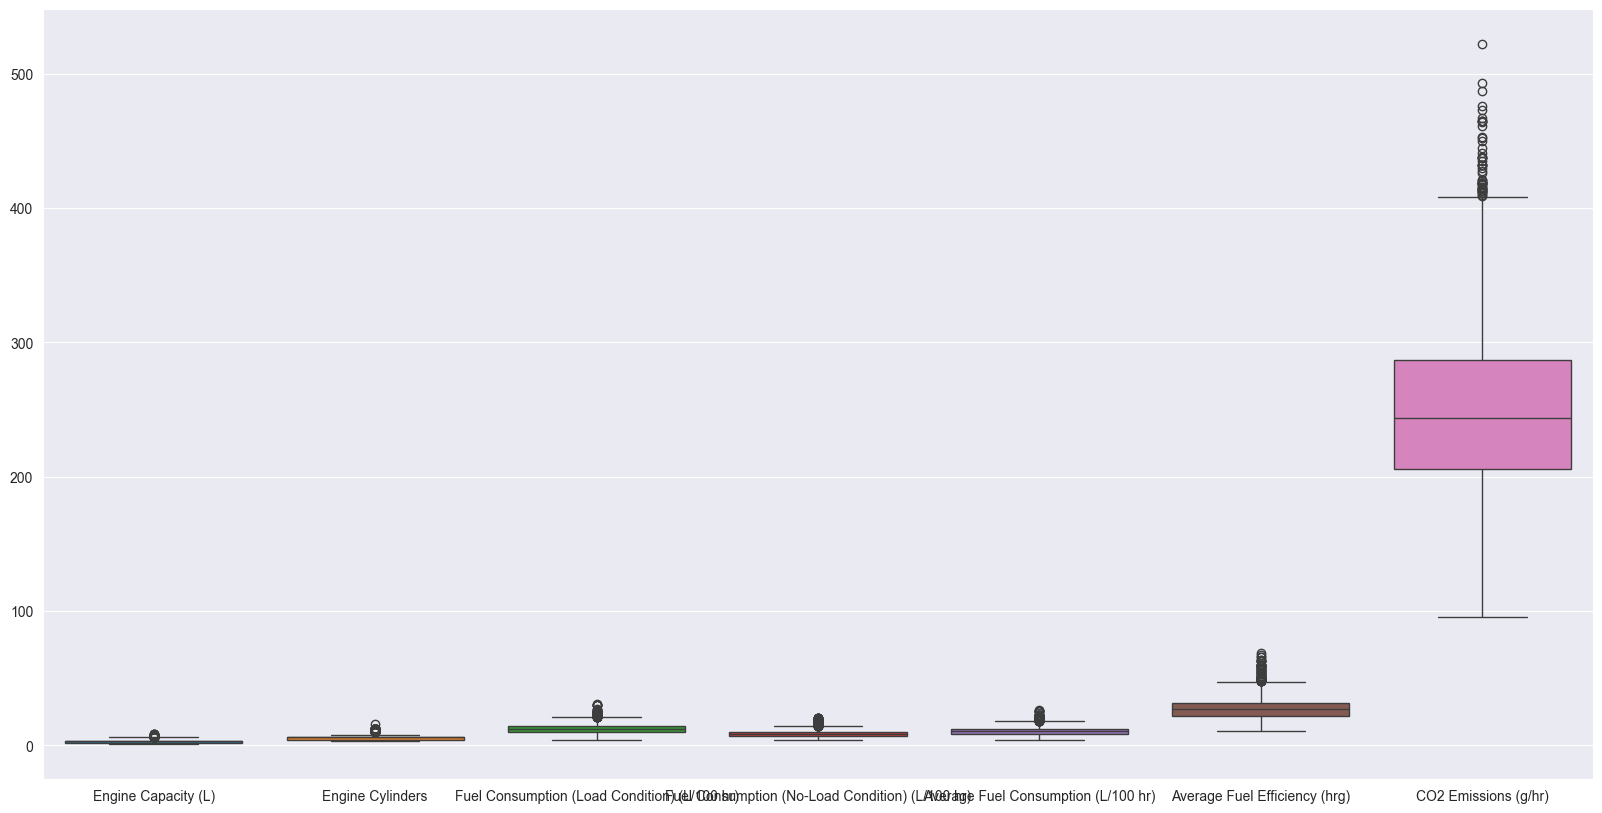

In [331]:
plt.figure(figsize=(20, 10))
sns.boxplot(data=train_df[numerical_columns])
plt.show()

As observed in the boxplot, there are potential outliers in the dataset. Since the dataset represents machines, and upon analyzing the distributions, it's clear that these outliers are present consistently across different features, I concluded that they are likely models that perform either better or worse than the others, rather than meaningless values. Based on this reasoning, I decided to keep them and not remove any additional data in order to avoid losing information.


## 1.5) Visualize the pair plot to understand the pairwise relationship. 

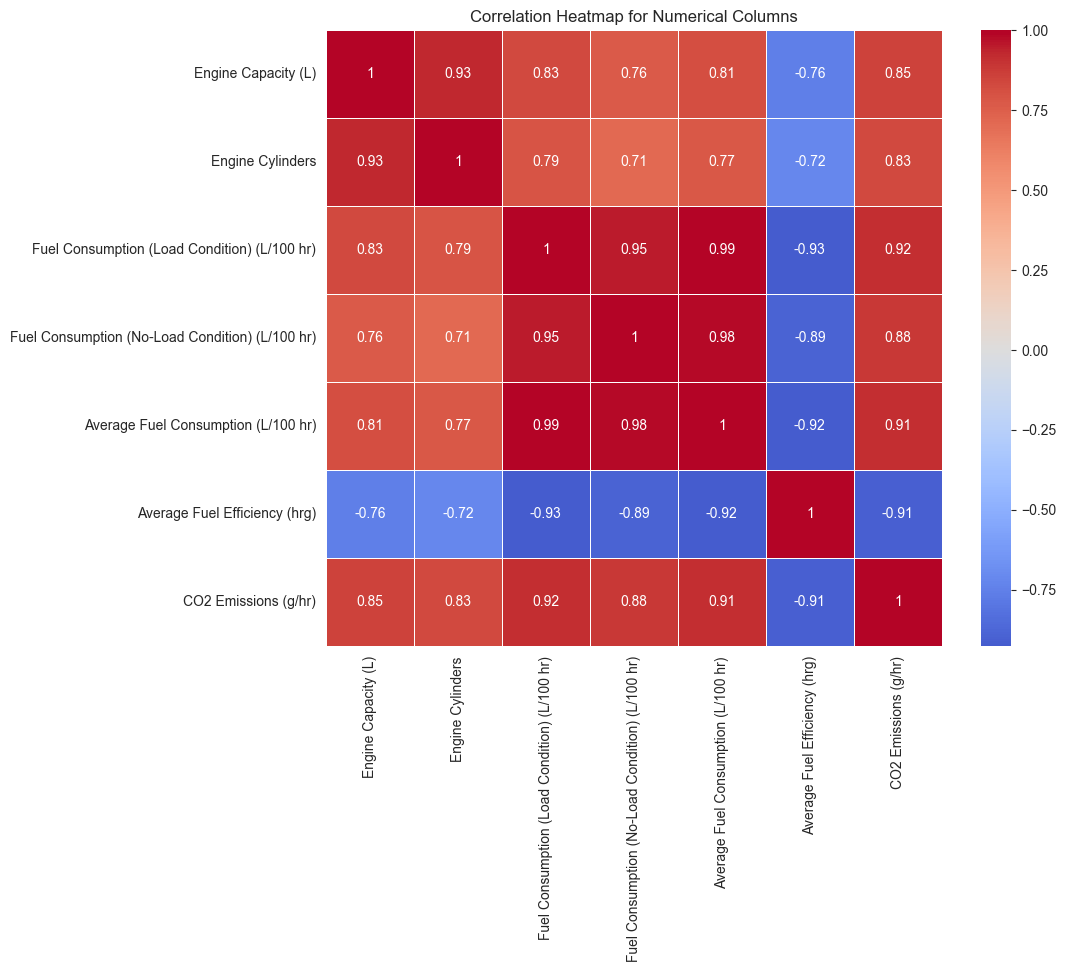

In [332]:
correlation_matrix = train_df[numerical_columns].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0, square=True, linewidths=0.5)

plt.title("Correlation Heatmap for Numerical Columns")

plt.show()

By examining the heatmap, we can observe that the features in the dataset are highly correlated with each other, with some correlations reaching as high as 0.99 (for example, between **Fuel Consumption** and **Average Fuel Consumption**). This heatmap is crucial because it allows us to understand that only a few features are necessary for accurate classification or prediction.

The high correlation between features means that the information captured by variables like **Fuel Consumption** and **Average Fuel Consumption** is very similar. As a result, we could eliminate one of these variables without losing significant information, simplifying the model and reducing its complexity.

Based on these observations, when performing **feature selection**, we can significantly reduce the number of features without sacrificing important information for the model. This will not only make the model less complex but also more efficient and easier to interpret.


The presence of correlations between features provides useful insights for feature selection, as some models do not account for correlations between features (e.g., Univariate Method).


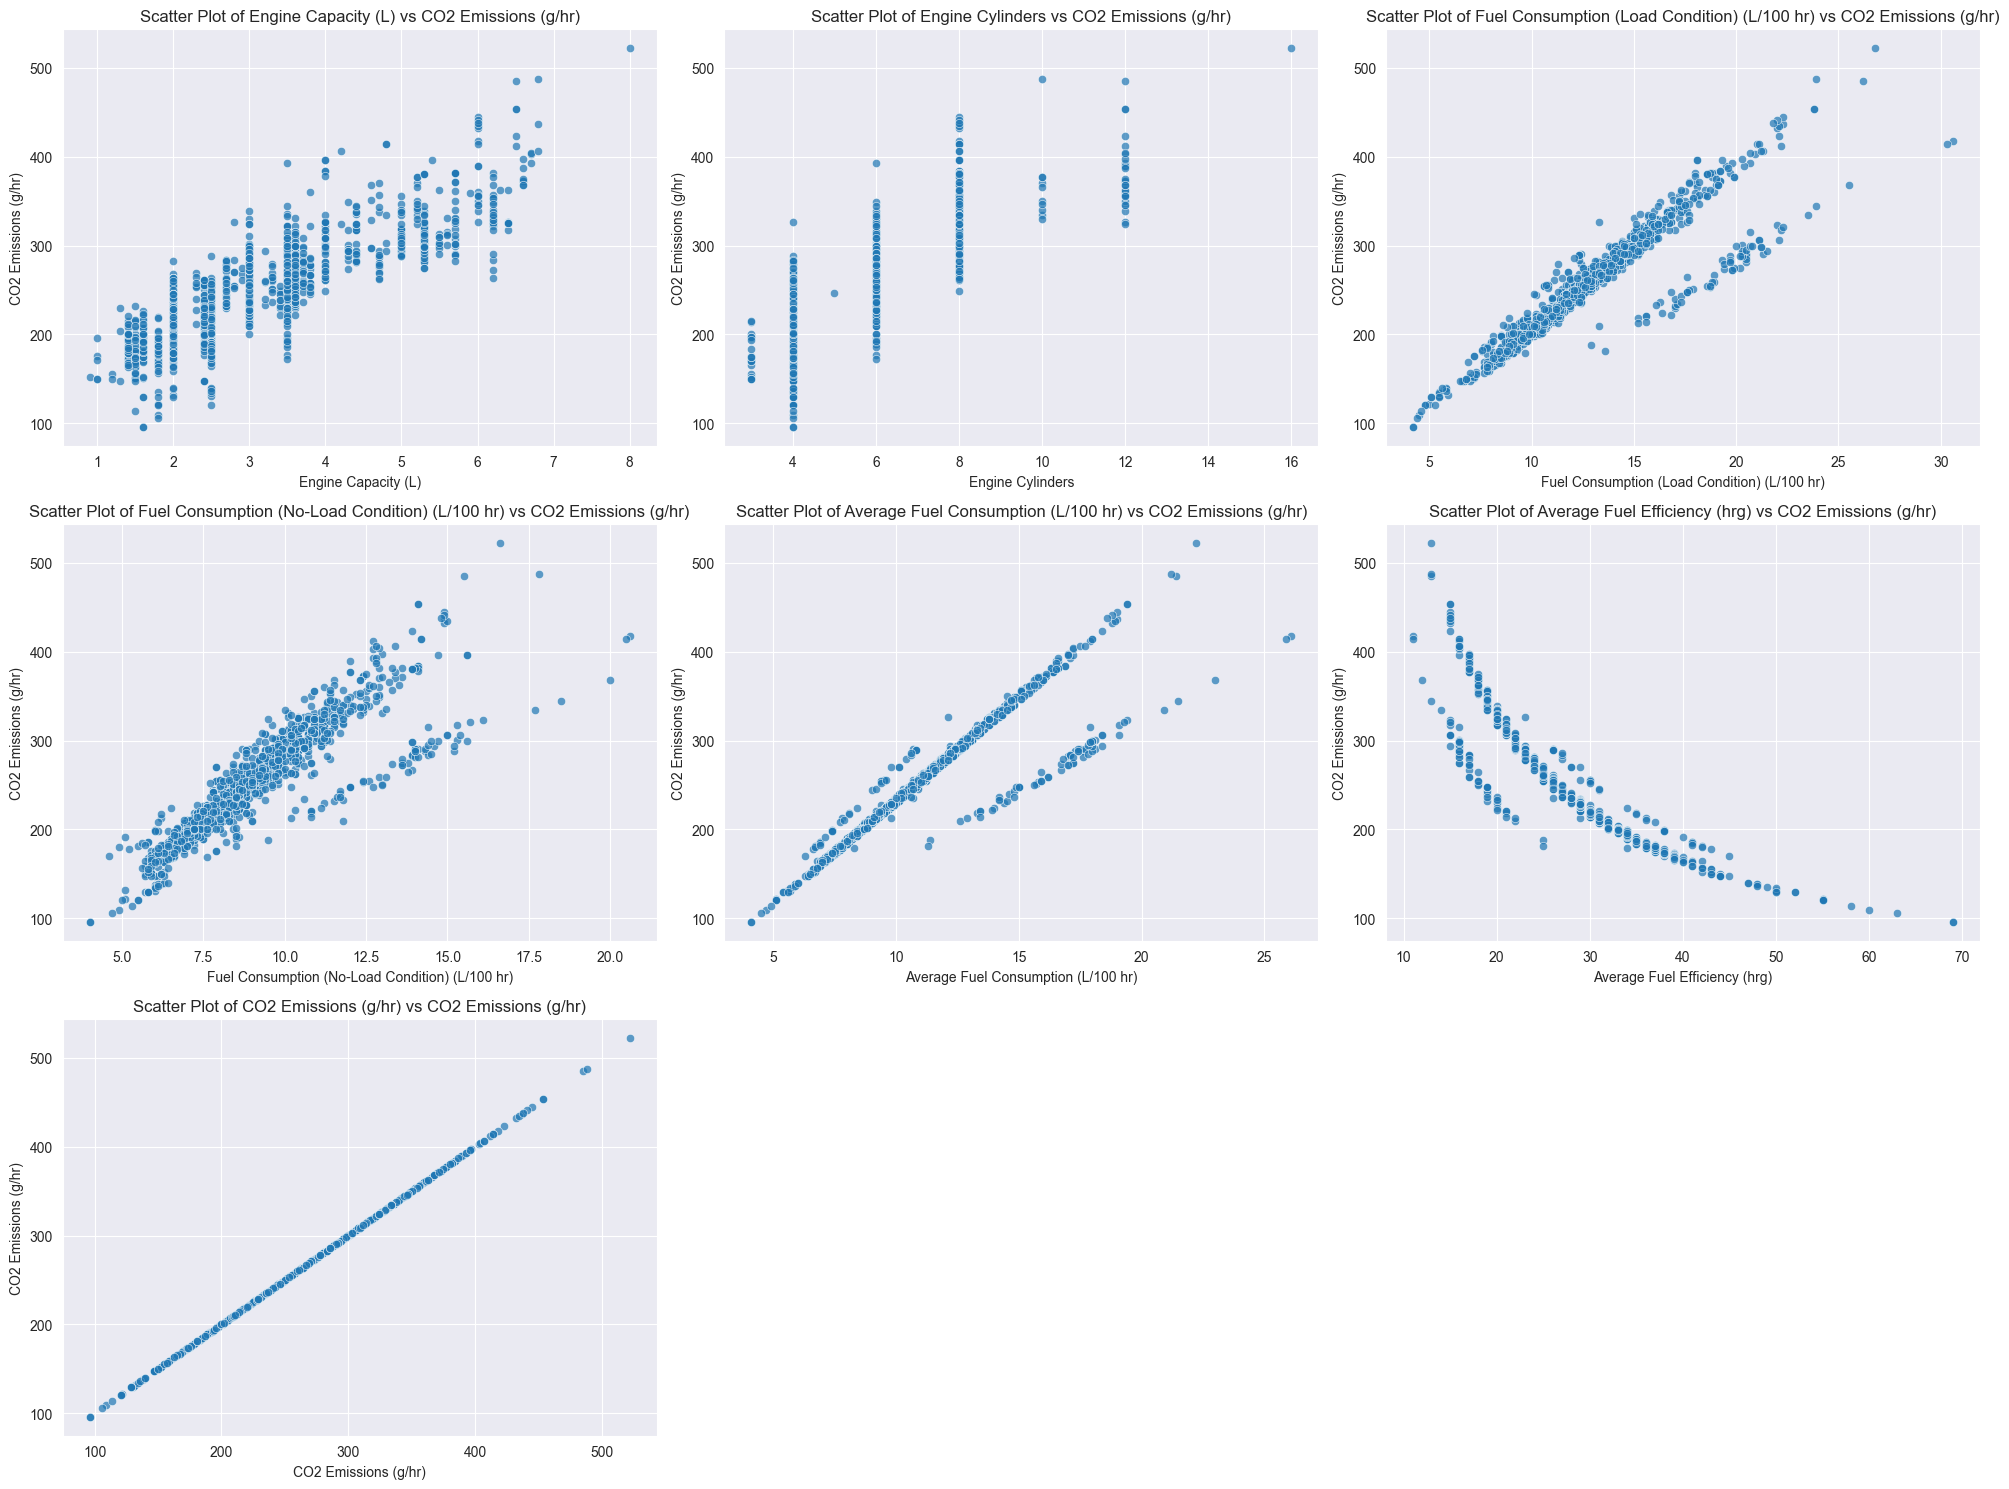

In [333]:
n_cols = 3  # Number of columns
n_rows = (len(numerical_columns) + n_cols - 1) // n_cols  # Calc num of rows

plt.figure(figsize=(20, 5 * n_rows))

for i, col in enumerate(numerical_columns):
    plt.subplot(n_rows, n_cols, i + 1)
    
    sns.scatterplot(data=test_df, x=col, y='CO2 Emissions (g/hr)', alpha=0.7)
    
    plt.title(f'Scatter Plot of {col} vs CO2 Emissions (g/hr)')
    plt.xlabel(col)
    plt.ylabel('CO2 Emissions (g/hr)')

plt.tight_layout()
plt.show()

Similar to the heatmap analysis, we can observe that **Fuel Consumption** has a strong correlation with the target variable, **CO2 Emissions (g/hr)**, which will be used for the regression task. This indicates that features such as **Average Fuel Efficiency** and various **Fuel Consumption** variables (both under load and no-load conditions) will be very important for the model. 

These relationships highlight that fuel consumption and efficiency are key factors in predicting CO2 emissions, and thus, these features will play a critical role in building an accurate model for the regression task.


## 1.6) Explore distribution  

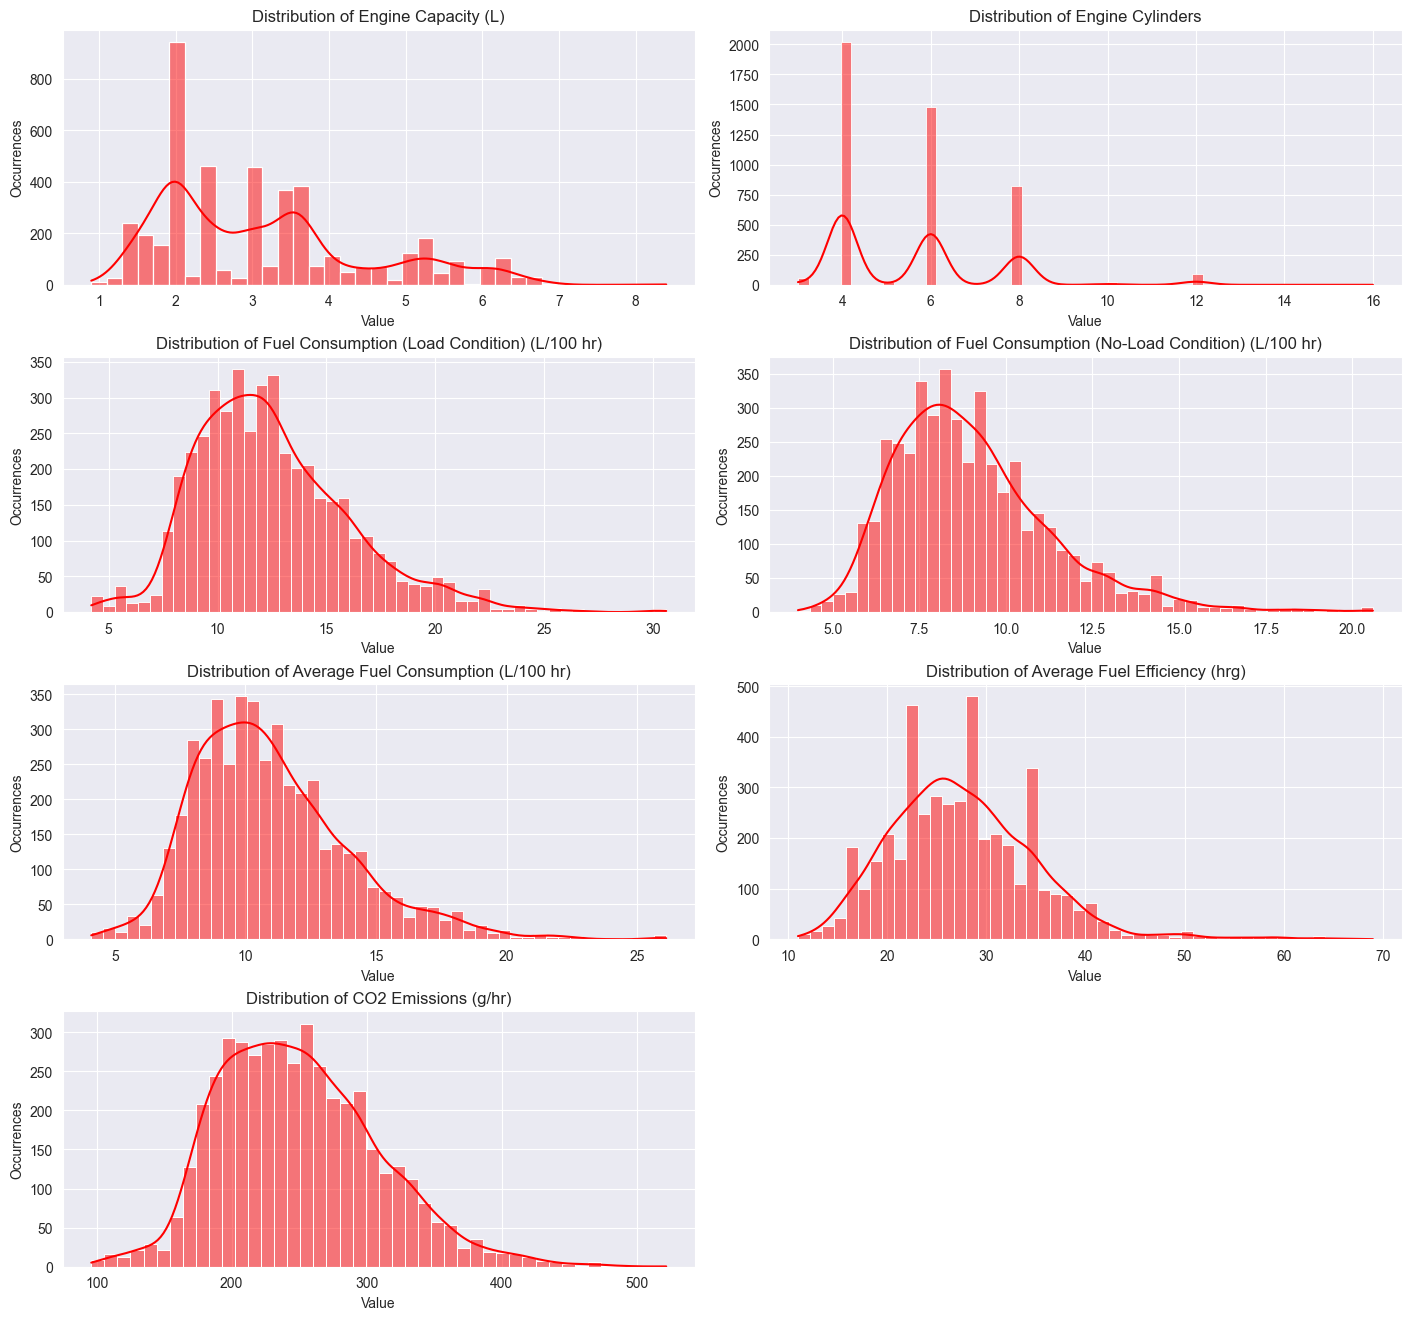

In [334]:
plot_distribution(train_df, numerical_columns,kde=True)

From the distributions, we can observe the presence of outliers, as previously analyzed. In general, we can notice that the continuous numerical features have a slight **right-skewed distribution**.

- **Engine Cylinders**: This feature does not follow a normal distribution and is a **discrete numerical variable**. 
  
- **Engine Capacity**: We can observe that **Engine Capacity** has several peaks and does not follow a Gaussian distribution. To simplify this feature and reduce model complexity, **binning** can be applied. Binning will allow us to group the values into categories, making the model more interpretable.

### 1.6.1) Apply binning technique for Engine Capacity(L) 

In [335]:
# Define bine on train set
bins = [0, 2, 4, 6, np.inf]  
labels = [0,1,2,3]

train_df['Engine Capacity (L)'] = pd.cut(train_df['Engine Capacity (L)'], bins=bins, labels=labels)

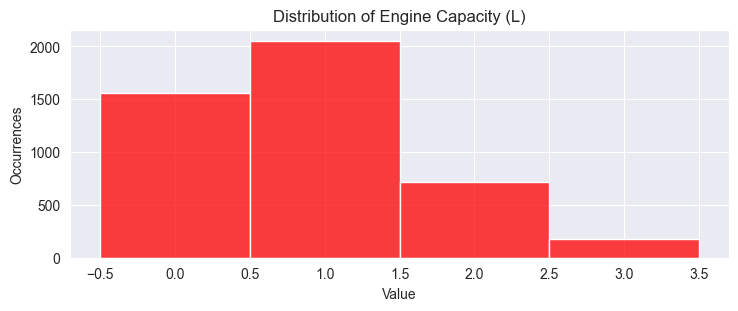

In [336]:
plot_distribution(train_df, ['Engine Capacity (L)'],kde=False)

## 1.7) Feauture Encoding 

### 1.7.1) One-hot-Encoding

In [337]:
# List of categorical columns to encode
columns_to_encode = ['Manufacturer', 'Machinery Category', 'Transmission Type', 'Fuel Category','Machine Model']

# Apply one-hot encoding to train set
train_df_encoded = pd.get_dummies(train_df, columns=columns_to_encode, prefix=columns_to_encode, dummy_na=False)

# Apply one-hot encoding to test set
test_df_encoded = pd.get_dummies(test_df, columns=columns_to_encode, prefix=columns_to_encode, dummy_na=False)

# Align test set columns to match train set columns
test_df_encoded = test_df_encoded.reindex(columns=train_df_encoded.columns, fill_value=0)


After grouping the low-frequency values and limiting the number of unique values, we can now apply **One-Hot Encoding** to these 5 features, as they do not follow a specific order.


### 1.7.2) Ordinal Encoding

#### CO2 Emissions Level

In [338]:
encoding_dict = {
    "very low": 0, 
    "low": 1, 
    "medium": 2, 
    "high": 3
}

train_df_encoded['CO2 Emissions Level'] = train_df_encoded['CO2 Emissions Level'].map(encoding_dict)

test_df_encoded['CO2 Emissions Level'] = test_df_encoded['CO2 Emissions Level'].map(encoding_dict)

print(f"CO2 Emissions Level in X_train -> {train_df_encoded['CO2 Emissions Level'].unique()}")
print(f"CO2 Emissions Level in X_test -> {test_df_encoded['CO2 Emissions Level'].unique()}")


CO2 Emissions Level in X_train -> [3 2 1 0]
CO2 Emissions Level in X_test -> [3 2 1 0]


For the feature **CO2 Emissions** , we apply **Ordinal Encoding** 


In [339]:
# Print the shapes for verification
print(f"X_train shape after encoding: {train_df_encoded.shape}")
print(f"X_test shape after encoding: {test_df_encoded.shape}")

X_train shape after encoding: (4512, 135)
X_test shape after encoding: (1477, 135)


As we can see, the dataset consists of 135 features, which makes it complex. This is not an issue, as feature selection will be performed to simplify the dataset and retain only the most relevant features for the model.








## 1.8) Split y_test and y_train 

In [340]:
y_train = train_df_encoded["CO2 Emissions Level"]
train_df_encoded = train_df_encoded.drop(columns=["CO2 Emissions Level"])

y_test = test_df_encoded["CO2 Emissions Level"]
test_df_encoded = test_df_encoded.drop(columns=["CO2 Emissions Level"])


In [341]:
y_train_reg = train_df_encoded["CO2 Emissions (g/hr)"]
train_df_encoded = train_df_encoded.drop(columns=["CO2 Emissions (g/hr)"])

y_test_reg = test_df_encoded["CO2 Emissions (g/hr)"]
test_df_encoded = test_df_encoded.drop(columns=["CO2 Emissions (g/hr)"])


To avoid compromising the models, both target variables are removed from the dataset. If we were to include the regression target in the classification dataset, we would achieve an accuracy of 100%, as both targets are identical.

## 1.9) Feauture selection 

### 1.9.1) Univariate Method (Select_percentile)


X_train_knn.shape: (4512, 133)
X_train_selected.shape: (4512, 40)
Index(['Engine Capacity (L)', 'Engine Cylinders',
       'Fuel Consumption (Load Condition) (L/100 hr)',
       'Fuel Consumption (No-Load Condition) (L/100 hr)',
       'Average Fuel Consumption (L/100 hr)', 'Average Fuel Efficiency (hrg)',
       'Manufacturer_Audi Industrial Equipment',
       'Manufacturer_Bauer Machinery Works',
       'Manufacturer_General Manufacturing Corporation',
       'Manufacturer_Honda Heavy Industries',
       'Manufacturer_Hyundai Manufacturing Solutions',
       'Manufacturer_Mazda Manufacturing Corp.',
       'Manufacturer_Mini Industrial Tools',
       'Manufacturer_Mitsubishi Industrial Equipment',
       'Manufacturer_Toyota Heavy Machinery',
       'Manufacturer_Volkswaren Machine Systems',
       'Machinery Category_Compact Utility Equipment',
       'Machinery Category_Light-Duty Transport Machinery',
       'Machinery Category_Mid-Sized Utility Machines',
       'Machinery Catego

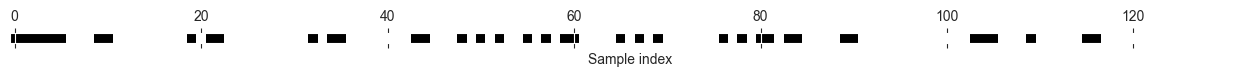

In [342]:

# SelectPercentile to select 30% of features
select = SelectPercentile(percentile=30)
select.fit(train_df_encoded, y_train)

# transform train set
X_train_selected = select.transform(train_df_encoded)
print("X_train_knn.shape: {}".format(train_df_encoded.shape))
print("X_train_selected.shape: {}".format(X_train_selected.shape))

mask = select.get_support()


# visualize the mask -- black is True, white is False
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())

selected_columns_un = train_df_encoded.columns[mask]
print(selected_columns_un)

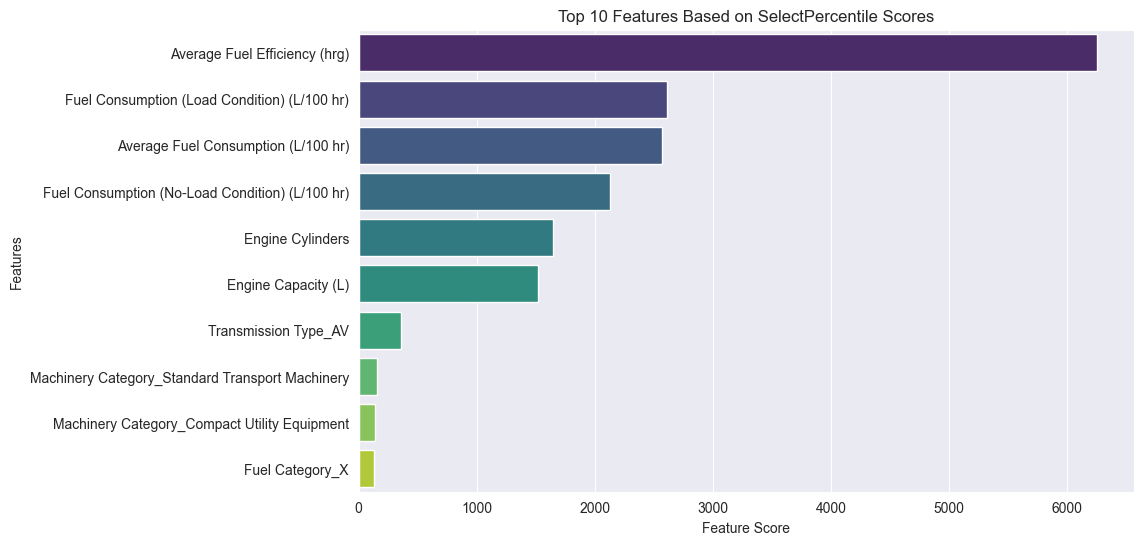

In [343]:

# Get top 10 features based on their scores
top_10_features = train_df_encoded.columns[select.scores_.argsort()[-10:][::-1]]
top_10_scores = select.scores_[select.scores_.argsort()[-10:][::-1]]

# Create a bar plot
plt.figure(figsize=(10, 6))
sns.barplot(x=top_10_scores, y=top_10_features, hue=top_10_features, palette='viridis', legend=False)

# Add labels
plt.xlabel('Feature Score')
plt.ylabel('Features')
plt.title('Top 10 Features Based on SelectPercentile Scores')
plt.show()


### 1.9.2) Iterative method (RandomForest)

Index(['Engine Capacity (L)', 'Engine Cylinders',
       'Fuel Consumption (Load Condition) (L/100 hr)',
       'Fuel Consumption (No-Load Condition) (L/100 hr)',
       'Average Fuel Consumption (L/100 hr)', 'Average Fuel Efficiency (hrg)',
       'Manufacturer_Cadillac Engineering Solutions',
       'Manufacturer_Chevrolet Engineering Works',
       'Manufacturer_Ford Industrial Corp.',
       'Manufacturer_Mercedes Industrial Solutions',
       'Manufacturer_Mini Industrial Tools',
       'Manufacturer_Porsche Engineering Works',
       'Machinery Category_Compact Utility Equipment',
       'Machinery Category_Heavy-Duty Utility Machinery',
       'Machinery Category_Small Utility Vehicle',
       'Machinery Category_Subcompact Utility Machinery',
       'Transmission Type_A6', 'Transmission Type_A9', 'Transmission Type_AM6',
       'Transmission Type_AM7', 'Transmission Type_AS6',
       'Transmission Type_AS9', 'Transmission Type_AV6',
       'Transmission Type_M5', 'Fuel Category

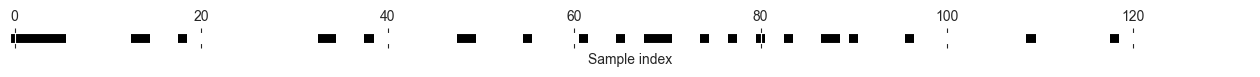

In [344]:


select = RFE(RandomForestRegressor(n_estimators=15, random_state=42), n_features_to_select=30)

select.fit(train_df_encoded, y_train)
# visualize the selected features:
mask = select.get_support() #mask of selected features
plt.matshow(mask.reshape(1, -1), cmap='gray_r')
plt.xlabel("Sample index")
plt.yticks(())


selected_columns_it = train_df_encoded.columns[mask]
display(selected_columns_it)

### 1.10.3) Model-based method with LinearModel

In [345]:


# Fit the LinearRegression model
model = LinearRegression()
model.fit(train_df_encoded, y_train)

# Get the absolute values of coefficients
coef_abs = np.abs(model.coef_)

# Get the indices of the top 30 most important features
top_30_indices = np.argsort(coef_abs)[-30:][::-1]  # Sort in descending order and take the top 30

# Select only the top 30 features
X_train_top_30 = train_df_encoded.iloc[:, top_30_indices]

# Get the names of the top 30 features
top_30_feature_names = train_df_encoded.columns[top_30_indices]

# Output the shapes
print("Original X_train shape: {}".format(train_df_encoded.shape))
print("Top 30 X_train shape: {}".format(X_train_top_30.shape))


Original X_train shape: (4512, 133)
Top 30 X_train shape: (4512, 30)


### 1.10.4) Selection based on the 3 model above

In [346]:
# Convert lists to sets to enable union
selected_columns_un_set = set(selected_columns_un)
selected_columns_it_set = set(selected_columns_it)
selected_columns_mb_set = set(top_30_feature_names)

# Find elements that are present in at least two of the three sets
common_columns = {col for col in selected_columns_un_set | selected_columns_it_set | selected_columns_mb_set
                  if sum([col in selected_columns_un_set, col in selected_columns_it_set, col in selected_columns_mb_set]) >= 2}

display(common_columns)


{'Average Fuel Consumption (L/100 hr)',
 'Average Fuel Efficiency (hrg)',
 'Engine Capacity (L)',
 'Engine Cylinders',
 'Fuel Category_D',
 'Fuel Category_E',
 'Fuel Category_X',
 'Fuel Category_Z',
 'Fuel Consumption (Load Condition) (L/100 hr)',
 'Fuel Consumption (No-Load Condition) (L/100 hr)',
 'Machine Model_FCSV',
 'Machinery Category_Compact Utility Equipment',
 'Machinery Category_Small Utility Vehicle',
 'Manufacturer_Audi Industrial Equipment',
 'Manufacturer_Bauer Machinery Works',
 'Manufacturer_Cadillac Engineering Solutions',
 'Manufacturer_Ford Industrial Corp.',
 'Manufacturer_General Manufacturing Corporation',
 'Manufacturer_Honda Heavy Industries',
 'Manufacturer_Mercedes Industrial Solutions',
 'Manufacturer_Mini Industrial Tools',
 'Manufacturer_Mitsubishi Industrial Equipment',
 'Manufacturer_Porsche Engineering Works',
 'Manufacturer_Toyota Heavy Machinery',
 'Transmission Type_A6',
 'Transmission Type_AM6',
 'Transmission Type_AV6',
 'Transmission Type_M5'}

In [347]:
train_df_reduced = train_df_encoded[list(common_columns)].copy()
test_df_reduced = test_df_encoded[list(common_columns)].copy()

In [348]:
print(f"train after selection: {train_df_reduced.shape}")
print(f"test after selection: {test_df_reduced.shape}")

train after selection: (4512, 28)
test after selection: (1477, 28)


For feature selection, **three methods** were applied.
For the SelectPercentile method, 30% was used to avoid the situation where there are too many features that appear in at least two selections.
**Final Selection Strategy**
- After applying the three methods, features that were selected by at least **two out of the three** methods were retained.

# 2) Softmax Regression 

### 2.1) Feauture Scaling 

In [349]:
scaler = RobustScaler()
train_df_scaled = scaler.fit_transform(train_df_reduced)
test_df_scaled = scaler.transform(test_df_reduced)

To ensure consistent feature scaling and improve the model's robustness to outliers, a **RobustScaler** is applied to all features. This method scales the data based on the **median** and **interquartile range (IQR)**, making it less sensitive to extreme values. By using the **RobustScaler**, we ensure that each feature has a similar scale, which helps the model train more effectively.

### 2.2) Find best model 

C:\Users\Sergio\Programs\Year 2\Supervised Learning\first_classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
C:\Users\Sergio\Programs\Year 2\Supervised Learning\first_classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative

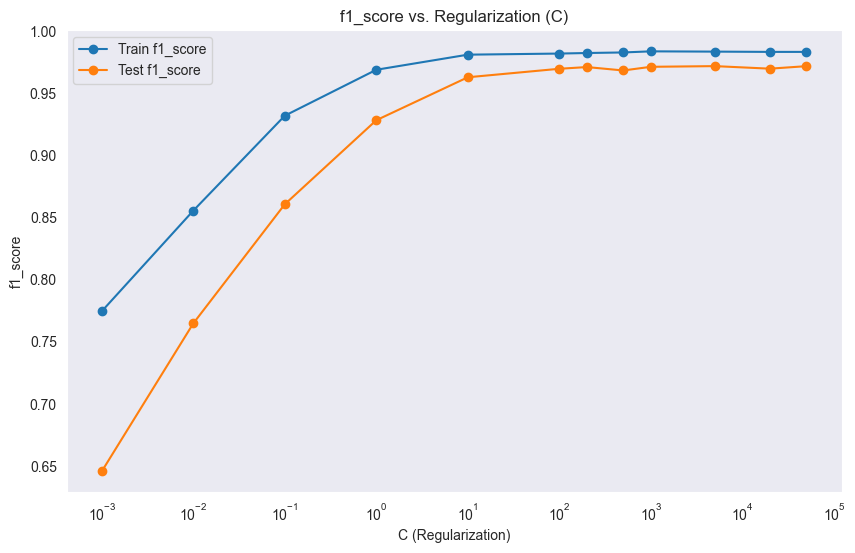

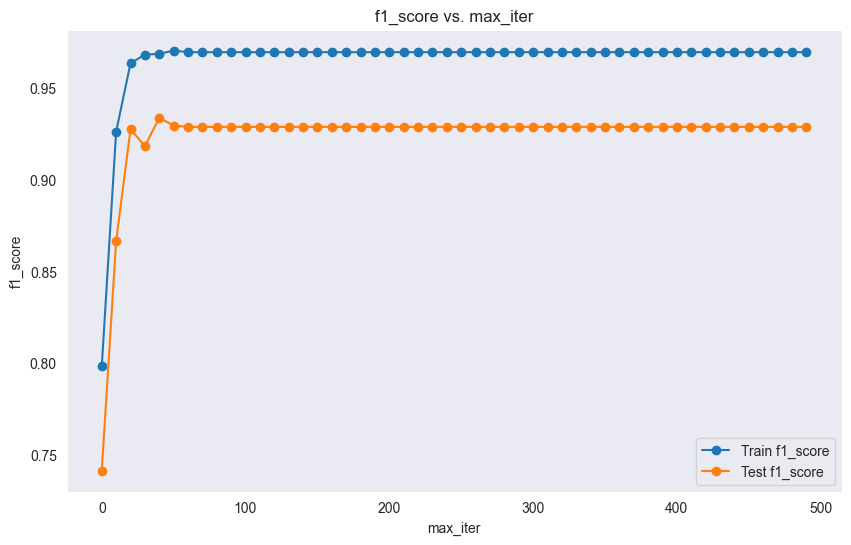

In [350]:
# Evaluation for "C"
C_values = [0.001, 0.01, 0.1, 1, 10, 100, 200, 500, 1000, 5000, 20000, 50000]
train_acc_C, test_acc_C = evaluate_hyperparameter_linear("C", C_values, {"solver": "lbfgs", "max_iter": 500},train_df_scaled,y_train,test_df_scaled,y_test)

# Evaluation for "max_iter"
max_iter_values = np.arange(0, 500, 10)
train_acc_iter, test_acc_iter = evaluate_hyperparameter_linear("max_iter", max_iter_values, {"solver": "lbfgs", "C": 1},train_df_scaled,y_train,test_df_scaled,y_test)

# Plot results
plot_results_softmax(C_values, train_acc_C, test_acc_C, "C (Regularization)", "f1_score vs. Regularization (C)")
plot_results_softmax(max_iter_values, train_acc_iter, test_acc_iter, "max_iter", "f1_score vs. max_iter")


For hyperparameter tuning, the **F1 score** was chosen instead of accuracy, as the dataset is imbalanced. The **F1 score** provides a better measure of model performance, especially in cases where class imbalance is present, as it takes both precision and recall into account.

Two plots were used to tune the hyperparameters:
1. **F1 Score vs. C**: This plot helps us evaluate the optimal value for the **regularization parameter (C)**.
   - To select the best **C**, we look for the value at which the **F1 score** plateaus. A very high **C** would reduce regularization, making the model vulnerable to overfitting.

2. **F1 Score vs. max_iter**: This plot helps us determine the ideal **max_iter** value, which controls the number of iterations during model training.
   - Similar to **C**, we choose the value where the **F1 score** stabilizes, limiting the number of iterations while still achieving the best score.

Final Values:
- **C = 10**
- **max_iter = 100**

Error Explanation:
The errors in the code are related to the **max_iter plot**, where the values of **max_iter** used for plotting are too low, affecting the plot's accuracy and stability.

### 2.2) Evaluate the model with best parameters

              precision    recall  f1-score   support

           0       0.94      0.94      0.94        32
           1       0.98      0.94      0.96       279
           2       0.97      0.93      0.95       472
           3       0.95      1.00      0.98       694

    accuracy                           0.96      1477
   macro avg       0.96      0.95      0.96      1477
weighted avg       0.96      0.96      0.96      1477

F1 Score (weighted): 96.32%


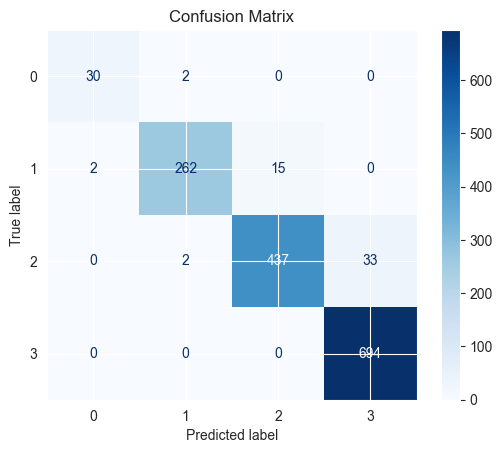

In [351]:
# Define the model with multinomial (softmax) configuration
best_softmax = LogisticRegression(solver="lbfgs",C=10,max_iter=100)

# Fit the model on the training data
best_softmax.fit(train_df_scaled, y_train)

# Predict on the test set
y_pred_softmax_cv_train = best_softmax.predict(train_df_scaled)
y_pred_softmax_cv = best_softmax.predict(test_df_scaled)

# Plot confusion matrix for the model
plot_confusion_matrix(best_softmax, y_test, y_pred_softmax_cv,True)


To evaluate the performance of the **Softmax** model, we use two metrics: the **classification report** and the **confusion matrix**.

From the **classification report**, we can observe that the model performs very well, achieving an **F1 score of 96.32%**. Additionally, the most frequent class (**class 3**) is the best predicted, with a **recall of 100%** and **precision of 95%**. 

The **confusion matrix** reveals that the misclassifications for **class 3** are minimal, with a total of **33 instances incorrectly predicted as class 3 instead of class 2**. Furthermore, the confusion matrix highlights the main sources of error, which occur when **class 2** is predicted as **class 3**, and **class 1** is predicted as **class 2**.

By comparing the **confusion matrix** and **F1 scores** achieved by both train and test, we can conclude that the model is neither overfitting nor underfitting. Both the **training** and **test** datasets show good performance, with the model performing slightly better on the training set, which is expected.




# 3) DecisionTree 

### 3.1) Find best model 

In [352]:
#Define the model and hyperparameter grid
decision_tree = DecisionTreeClassifier(random_state=42)
param_grid = {
    'max_depth': [1, 2,4, 10, 15,20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 5, 10],          # Minimum samples in a leaf node
    'criterion': ['gini', 'entropy']
}

#Perform Grid Search
grid_search = GridSearchCV(decision_tree, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(train_df_reduced, y_train)

# Print the best parameters and the best score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score(f1_score): {grid_search.best_score_:.4f}")

Best Hyperparameters: {'criterion': 'gini', 'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 5}
Best Cross-Validation Score(f1_score): 0.9760


C:\Users\Sergio\Programs\Year 2\Supervised Learning\first_classification\.venv\Lib\site-packages\numpy\ma\core.py:2881: RuntimeWarning: invalid value encountered in cast
  _data = np.array(data, dtype=dtype, copy=copy,


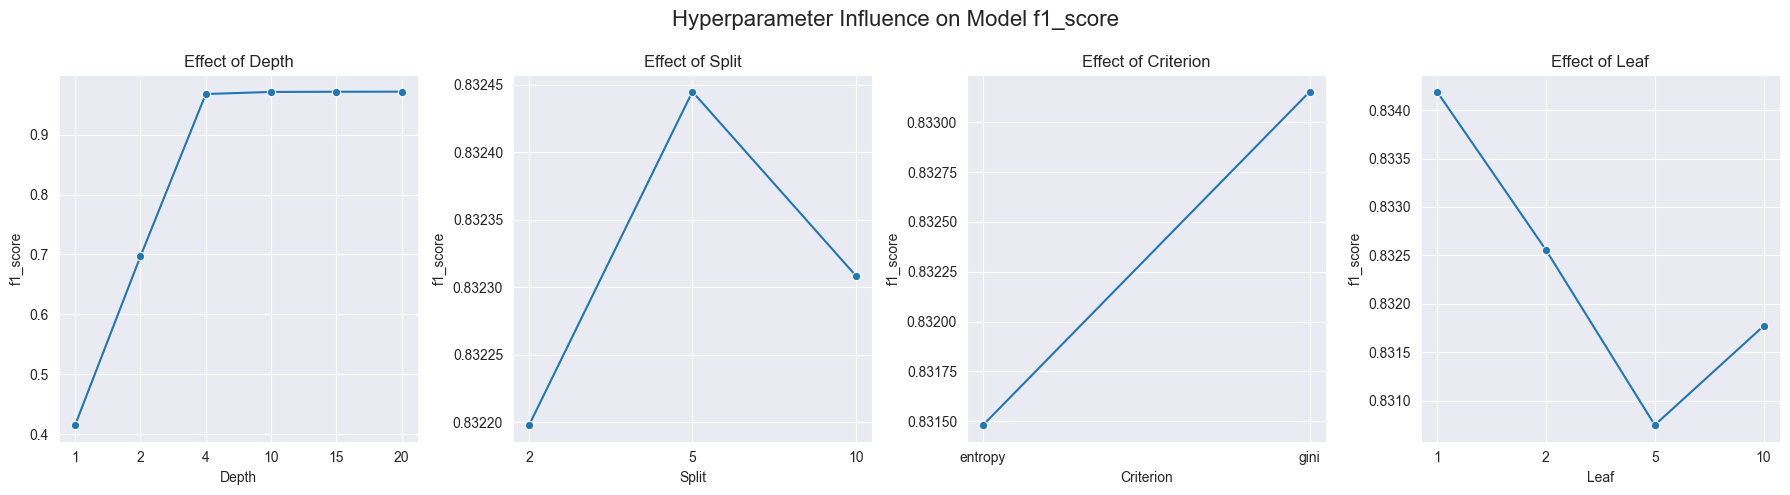

In [353]:
results = pd.DataFrame(grid_search.cv_results_)

# List of hyperparameters to visualize
params = ['param_max_depth', 'param_min_samples_split', 'param_criterion','param_min_samples_leaf']

#Create subplots to analyze the influence of each hyperparameter
fig, axes = plt.subplots(1, len(params), figsize=(18, 5))
fig.suptitle("Hyperparameter Influence on Model f1_score", fontsize=16)

# Plot each parameter's influence
for idx, param in enumerate(params):
    # Group results by the current parameter and calculate the mean test score
    param_means = results.groupby(param)['mean_test_score'].mean().reset_index()
    
    # Ensure categorical parameters are displayed correctly (e.g., 'criterion')
    param_means[param] = param_means[param].astype(str)
    
    # Line plot for accuracy against the parameter
    sns.lineplot(data=param_means, x=param, y='mean_test_score', ax=axes[idx], marker='o')
    axes[idx].set_title(f"Effect of {param.split('_')[-1].capitalize()}")
    axes[idx].set_ylabel("f1_score")
    axes[idx].set_xlabel(param.split('_')[-1].capitalize())

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

For tuning the **Decision Tree** model, we selected four key hyperparameters: **max_depth**, **min_samples_leaf**, **min_samples_split**, and **criterion**.

These hyperparameters were chosen primarily because, given the large number of features and samples in our dataset, we may encounter potential overfitting. By adjusting these parameters, we can simplify the Decision Tree and prevent it from becoming overly complex and fitting to noise in the data.

- **max_depth**: Controls the maximum depth of the tree, preventing it from growing too deep and capturing unnecessary details.
- **min_samples_split**: Reduce overfitting by ensuring that splits occur only when a significant number of samples are present.
- **min_samples_leaf**: Ensures that the tree does not create leaves with very few samples, which may capture noise.


Based on the analysis of the graphs, we selected the following hyperparameter values:

- **max_depth**: The value of **5** is chosen as it provides the highest F1 score. Increasing the depth further would complicate the model without improving performance, potentially leading to overfitting.
  
- **min_samples_split**: The value of **10** is selected to ensure that splits are only made when there are sufficient samples. This helps prevent overly specific splits that could capture noise in the data, improving the generalization of the model.

- **min_samples_leaf**: The F1 score initially decreases as **min_samples_leaf** increases from 1 to 5(possible overfitting), but starts to rise again at **5**. The best is 10 to ensure that the model create new leaf when we have data.



### 3.1) Evaluate the model with best parameters

              precision    recall  f1-score   support

           0       0.97      0.91      0.94        32
           1       0.98      0.92      0.95       279
           2       0.93      0.99      0.96       472
           3       0.99      0.98      0.99       694

    accuracy                           0.97      1477
   macro avg       0.97      0.95      0.96      1477
weighted avg       0.97      0.97      0.97      1477

F1 Score (weighted): 96.95%


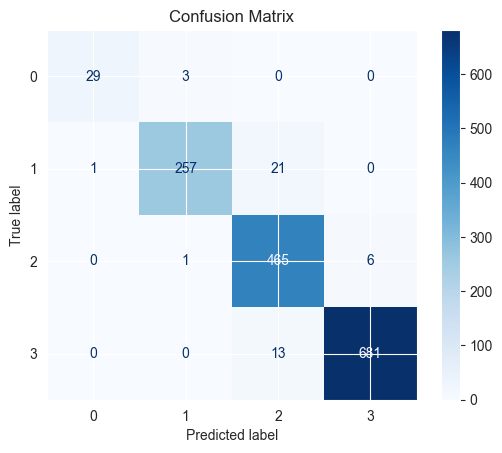

In [354]:
best_decision_tree = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=10,
    min_samples_leaf=10,
    criterion='gini',
    random_state=42
)
# Fit the model on the training data
best_decision_tree.fit(train_df_reduced, y_train)

# Make predictions on the test set
y_pred_decisiontree = best_decision_tree.predict(test_df_reduced)
y_pred_decisiontree_train = best_decision_tree.predict(train_df_reduced)

# Plot confusion matrix for the model
plot_confusion_matrix(best_decision_tree, y_test, y_pred_decisiontree, True)

To evaluate the performance of the **Decision Tree** model, we use two metrics: the **classification report** and the **confusion matrix**.

From the **classification report**, we can observe that the model performs very well, achieving an **F1 score (weighted) of 96.95%**. Additionally, the most frequent class (**class 3**) is the best predicted, with **precision of 99%** and **f1_score of 99%**,while the least represented class, **Class 0**, is the one with the lowest values.

The **confusion matrix** reveals that the misclassifications for **class 2** are minimal, with only **6 instances incorrectly predicted as class 3**. Furthermore, the confusion matrix highlights the main sources of error, which occur when **class 1** is predicted as **class 2**.

Overall, the **Decision Tree** model shows high accuracy and good generalization, with **minimal misclassifications** across all classes. Comparing the 2 values in train and test we can conclude that the model is not underfitting or overfitting.

# 4) Random Forest 

### 4.1) Find best model 

In [355]:
# Define the Random Forest Classifier
rf_classifier = RandomForestClassifier(oob_score=True)

# Define the hyperparameter grid to search
param_grid = {
    'n_estimators': [50,70,100],
    'min_samples_split': [2,5,10],
    'max_depth': [1, 2, 3, 4, 10, 20],
}

# Use GridSearchCV to find the best hyperparameters
grid_search = GridSearchCV(rf_classifier, param_grid, cv=5, scoring='f1_macro')
grid_search.fit(train_df_reduced, y_train)

# Print the best hyperparameters
# Print the best parameters and the best score
print(f"Best Hyperparameters: {grid_search.best_params_}")
print(f"Best Cross-Validation Score(f1_score): {grid_search.best_score_:.4f}")

Best Hyperparameters: {'max_depth': 10, 'min_samples_split': 10, 'n_estimators': 70}
Best Cross-Validation Score(f1_score): 0.9781


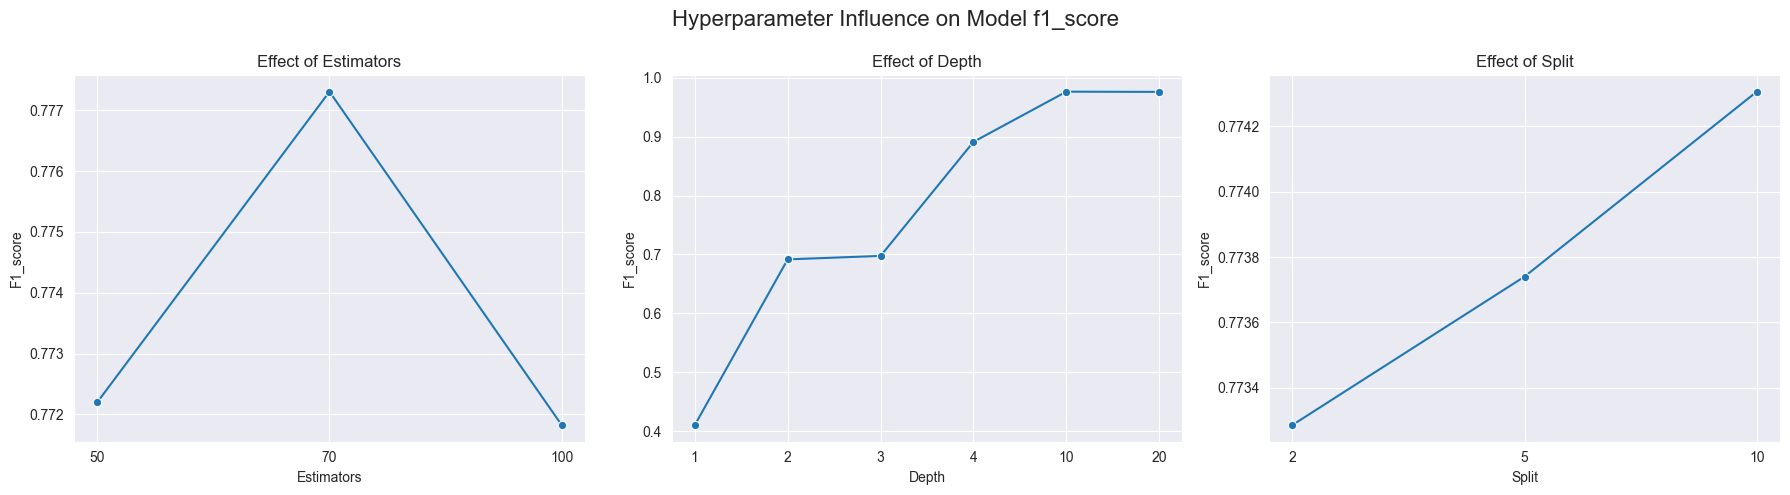

In [356]:
# Step 3: Extract results and prepare for visualization
results = pd.DataFrame(grid_search.cv_results_)

# List of hyperparameters to visualize
params = ['param_n_estimators', 'param_max_depth', 'param_min_samples_split']

# Step 4: Create subplots to analyze the influence of each hyperparameter
fig, axes = plt.subplots(1, len(params), figsize=(18, 5))
fig.suptitle("Hyperparameter Influence on Model f1_score", fontsize=16)

# Plot each parameter's influence
for idx, param in enumerate(params):
    # Group results by the current parameter and calculate the mean test score
    param_means = results.groupby(param)['mean_test_score'].mean().reset_index()
    
    # Ensure categorical parameters are displayed correctly
    param_means[param] = param_means[param].astype(str)
    
    # Line plot for accuracy against the parameter
    sns.lineplot(data=param_means, x=param, y='mean_test_score', ax=axes[idx], marker='o')
    axes[idx].set_title(f"Effect of {param.split('_')[-1].capitalize()}")
    axes[idx].set_ylabel("F1_score")
    axes[idx].set_xlabel(param.split('_')[-1].capitalize())

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

Similar to the approach used for training the **Decision Tree** model, we selected hyperparameters to minimize the risk of overfitting. To achieve this, we focused on tuning three key hyperparameters: **n_estimators**, **max_depth**, and **min_samples_split**.

We then created plots to visualize the impact of each hyperparameter on the model's performance.

- **n_estimators**: The optimal value for **n_estimators** is **50**, as it provides a high F1 score without making the model too complex. Increasing the number of estimators to **100** only results in a marginal improvement in F1 score (around 0.005), suggesting that higher values are unlikely to significantly improve the model's performance.

- **max_depth**: For the **max_depth** hyperparameter, we observe that a depth of **10** reaches a plateau in terms of performance. Further increases in depth do not provide meaningful gains, so it makes sense to keep it at this value to avoid unnecessarily complicating the model.

- **min_samples_split**: Similar to what we observed with the **Decision Tree** model, setting **min_samples_split** to **2** initially yields the best performance. However, allowing the model to split on fewer samples can lead to overfitting, as the model might become too specific and fit to noise in the dataset.



### 4.2) Evaluate the model with best parameters

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.98      0.96      0.97       279
           2       0.97      0.96      0.96       472
           3       0.97      0.99      0.98       694

    accuracy                           0.97      1477
   macro avg       0.98      0.95      0.97      1477
weighted avg       0.97      0.97      0.97      1477

F1 Score (weighted): 97.28%


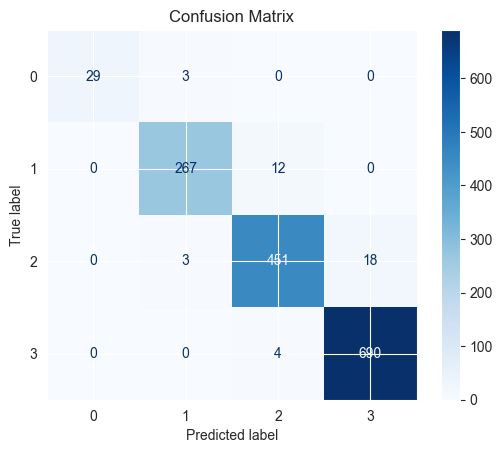

In [357]:
# Get the best estimator from grid search
best_rf = RandomForestClassifier(
    max_depth=10,
    min_samples_split=10,
    n_estimators=50,
    oob_score=True
)

# Fit the model on the training data
best_rf.fit(train_df_reduced, y_train)

# Make predictions on the test set
y_pred_rf_ = best_rf.predict(test_df_reduced)
y_pred_rf_train = best_rf.predict(train_df_reduced)

# Plot confusion matrix for the model
plot_confusion_matrix(best_rf, y_test, y_pred_rf_, True)

The **Random Forest** model outperforms the previous two models, achieving an impressive **F1 score of 97.28%**. From the **classification report**, we can observe that the least represented class, which struggled in earlier models, now achieves **100% precision**, indicating a significant improvement in prediction for that class.

Upon analyzing the **confusion matrix**, we can see that the **Random Forest** model performs similarly to the previous models, with the main issues being **class 1 predicted as class 2** and **9 instances of class 2 predicted as class 3**. These misclassifications are consistent with the patterns observed in the Decision Tree model, indicating similar areas for improvement.

In comparison to the **Decision Tree**, the **Random Forest** performs better overall, likely due to the ensemble approach, which reduces variance and improves generalization.


### 4.3) Provide an out-of-bag evaluation of the trained model.

In [386]:
evaluation = best_rf.oob_score_
print(f"Evaluation using out-of-bag: {evaluation}")
best_rf.oob_decision_function_

Evaluation using out-of-bag: 0.976063829787234


array([[0.00000000e+00, 0.00000000e+00, 9.97048767e-01, 2.95123348e-03],
       [0.00000000e+00, 1.52596682e-02, 9.77360636e-01, 7.37969559e-03],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00],
       ...,
       [0.00000000e+00, 1.19047619e-02, 9.88095238e-01, 0.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.01200007e-03, 9.98988000e-01],
       [0.00000000e+00, 3.53232073e-04, 2.18659237e-03, 9.97460176e-01]])

The **Random Forest** model achieved an **OOB score of 97.68%**, indicating strong generalization performance on unseen data. The **OOB decision function** shows that the model is confident in its predictions, with high probabilities for the correct class and low probabilities for incorrect ones. This evaluation method provides an effective measure of model performance without requiring a separate validation set.


# 5) AdaBoost Regularize the model: choose the hyperparameters you might tune. Reason on and justify which hyper-parameter

### 5.1) Find best model 

In [359]:
# Define the AdaBoost model with explicit SAMME algorithm
ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(),  # Weak learner
    algorithm='SAMME',                   # Use SAMME to avoid deprecation
    random_state=42                      # Ensure reproducibility
)

# Define the hyperparameter grid
param_grid = {
    'estimator__max_depth': [1, 2, 3,4,7],           # Tuning the weak learner's depth
    'n_estimators': [50, 100, 200],              # Number of weak learners
    'learning_rate': [0.1, 0.5, 1,2,4,5,10]             # Contribution of each weak learner
}

# Perform grid search with cross-validation
grid_search = GridSearchCV(ada_clf, param_grid, cv=5, scoring='f1_macro', verbose=1)
grid_search.fit(train_df_reduced, y_train)

# Print the best parameters and cross-validation score
print("Best Hyperparameters:", grid_search.best_params_)
print(f"Best Cross-Validation Accuracy: {grid_search.best_score_:.4f}")


Fitting 5 folds for each of 105 candidates, totalling 525 fits
Best Hyperparameters: {'estimator__max_depth': 3, 'learning_rate': 0.1, 'n_estimators': 200}
Best Cross-Validation Accuracy: 0.9779


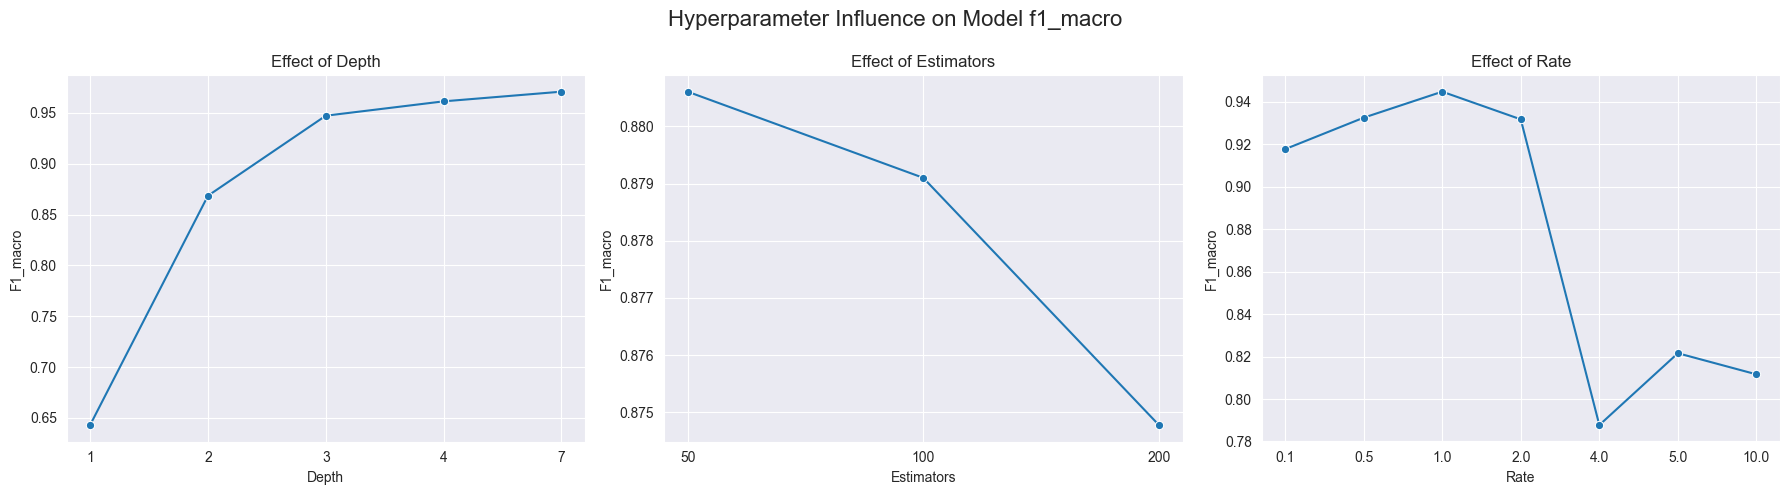

In [360]:
# Step 3: Extract results and prepare for visualization
results = pd.DataFrame(grid_search.cv_results_)

# List of hyperparameters to visualize
params = ['param_estimator__max_depth', 'param_n_estimators', 'param_learning_rate']

# Step 4: Create subplots to analyze the influence of each hyperparameter
fig, axes = plt.subplots(1, len(params), figsize=(18, 5))
fig.suptitle("Hyperparameter Influence on Model f1_macro", fontsize=16)

# Plot each parameter's influence
for idx, param in enumerate(params):
    # Group results by the current parameter and calculate the mean test score
    param_means = results.groupby(param)['mean_test_score'].mean().reset_index()
    
    # Ensure categorical parameters are displayed correctly
    param_means[param] = param_means[param].astype(str)
    
    # Line plot for accuracy against the parameter
    sns.lineplot(data=param_means, x=param, y='mean_test_score', ax=axes[idx], marker='o')
    axes[idx].set_title(f"Effect of {param.split('_')[-1].capitalize()}")
    axes[idx].set_ylabel("F1_macro")
    axes[idx].set_xlabel(param.split('_')[-1].capitalize())

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()


For **AdaBoost**, three hyperparameters were selected for tuning: **max_depth**, **n_estimators**, and **learning rate**. 

- **max_depth**: From the graph, we can see that the **F1 score** reaches its peak at **depth = 3**. Increasing the depth further does not lead to significant performance improvements but increases model complexity. Therefore, **depth = 3** is chosen as it strikes the best balance between performance and model simplicity.

- **n_estimators**: The **F1 score** shows minimal improvement between **50** and **200 estimators**. This suggests that adding more estimators beyond **50** does not meaningfully improve performance, so we choose **n_estimators = 50** to simplify the model without sacrificing accuracy.

- **Learning Rate**: The graph indicates that a **learning rate of 2** achieves the highest **F1 score**. This learning rate allows the model to learn efficiently without compromising its effectiveness. 

In conclusion, the selected hyperparameters are **max_depth = 3**, **n_estimators = 50**, and **learning rate = 2**, as they provide the best performance while maintaining a balance between model accuracy and simplicity.


### 5.2) Evaluate the model with best parameters 

              precision    recall  f1-score   support

           0       1.00      0.97      0.98        32
           1       0.99      0.91      0.95       279
           2       0.91      0.99      0.95       472
           3       0.99      0.97      0.98       694

    accuracy                           0.97      1477
   macro avg       0.97      0.96      0.97      1477
weighted avg       0.97      0.97      0.97      1477

F1 Score (weighted): 96.57%


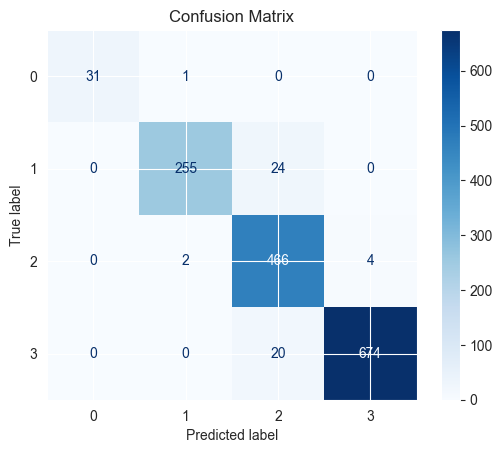

In [361]:
# Get the best estimator from grid search
best_ada_clf = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=3),  # Weak learner
    algorithm='SAMME',                   # Use SAMME to avoid deprecation
    random_state=42,
    learning_rate=2,
    n_estimators=50,
)

# Fit the model on the training data
best_ada_clf.fit(train_df_reduced, y_train)

# Evaluate the best model on the test set
y_pred_ada = best_ada_clf.predict(test_df_reduced)
y_pred_ada_train = best_ada_clf.predict(train_df_reduced)

# Plot the confusion matrix
plot_confusion_matrix(best_ada_clf, y_test, y_pred_ada,True)

Similar to the other models, we observe two main types of misclassifications: **class 1** predicted as **class 2**, and **class 2** predicted as **class 3**. But in this case we have also misclassifications for class 3 predicted as class 2 

Overall, the model achieved an **F1 score of 96.57%**, indicating strong performance.

# 6) Among the previously trained models (after hyperparameters optimization), select the models that allow soft voting and combine them into an ensemble. 

### 6.1) Evaluate the model 

In [362]:
# Create the VotingClassifier with soft voting
soft_voting_clf = VotingClassifier(
    estimators=[
        ('decision_tree', best_decision_tree),
        ('adaboost', best_ada_clf),
        ('random_forest', best_rf),
    ],
    voting='soft'
)

# Fit the VotingClassifier on the training data
soft_voting_clf.fit(train_df_reduced, y_train)


VotingClassifier(estimators=[('decision_tree',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_leaf=10,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('adaboost',
                              AdaBoostClassifier(algorithm='SAMME',
                                                 estimator=DecisionTreeClassifier(max_depth=3),
                                                 learning_rate=2,
                                                 random_state=42)),
                             ('random_forest',
                              RandomForestClassifier(max_depth=10,
                                                     min_samples_split=10,
                                                     n_estimators=50,
                                                     oob_score=True))],
                 voting='soft')

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.98      0.95      0.96       279
           2       0.96      0.98      0.97       472
           3       0.99      0.99      0.99       694

    accuracy                           0.98      1477
   macro avg       0.98      0.96      0.97      1477
weighted avg       0.98      0.98      0.98      1477

F1 Score (weighted): 97.70%


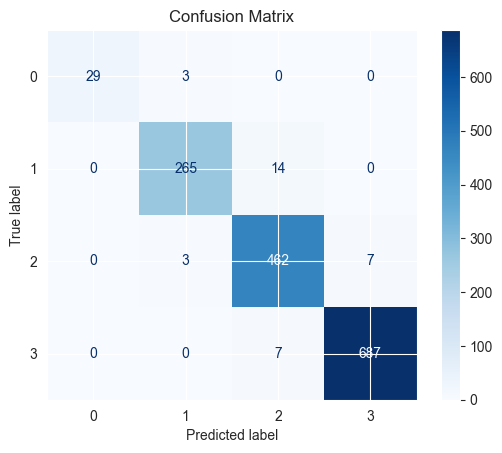

In [363]:
# Evaluate on the test set
y_pred_voting = soft_voting_clf.predict(test_df_reduced)
y_pred_voting_train = soft_voting_clf.predict(train_df_reduced)
# Plot confusion matrix for the model
plot_confusion_matrix(soft_voting_clf, y_test, y_pred_voting,True)

For the **soft voting** model, the following classifiers were used: **DecisionTree**, **AdaBoost**, and **RandomForest**. The **Softmax** model was discarded because it requires scaled input data.

### 6.2) Compare the soft voting classifier  performances with the individual classifier ones.

In [364]:
# Evaluate the weighted F1 score for each model
Dt_f1 = f1_score(y_test, y_pred_decisiontree, average='weighted')
Rf_f1 = f1_score(y_test, y_pred_rf_, average='weighted')
Ab_f1 = f1_score(y_test, y_pred_ada, average='weighted')
Sv_f1 = f1_score(y_test, y_pred_voting, average='weighted')

# Print the weighted F1 scores for each model
print(Dt_f1, Rf_f1, Ab_f1, Sv_f1)

0.9695491048894178 0.9728095717334933 0.9656679771714034 0.9769528158389681


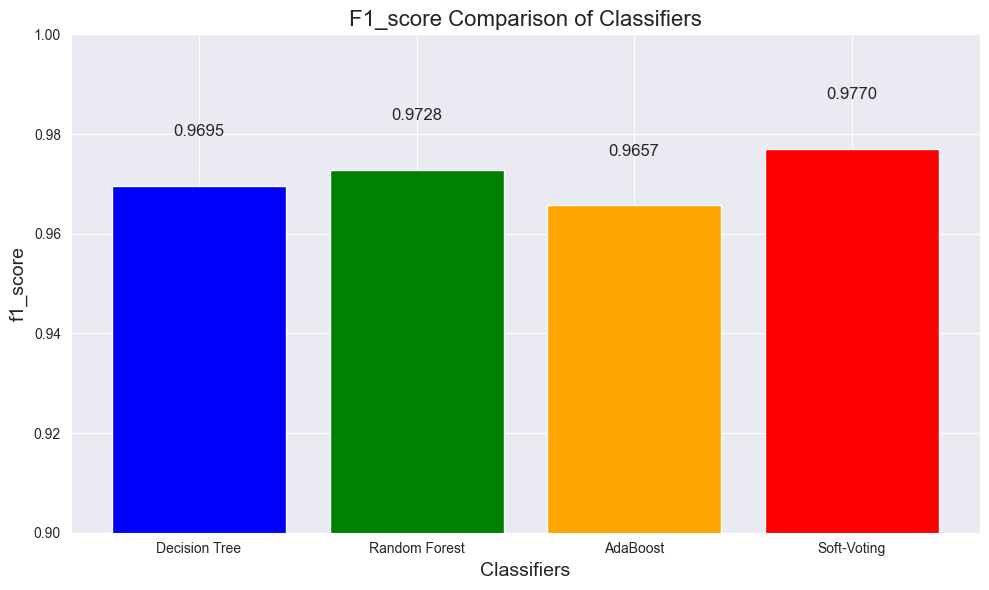

In [365]:
# Define the accuracy values
accuracy_values = [Dt_f1, Rf_f1, Ab_f1,Sv_f1]
models = ['Decision Tree', 'Random Forest','AdaBoost','Soft-Voting']

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_values, color=['blue', 'green', 'orange', 'red'])

# Add title and labels
plt.title('F1_score Comparison of Classifiers', fontsize=16)
plt.xlabel('Classifiers', fontsize=14)
plt.ylabel('f1_score', fontsize=14)
plt.ylim([0.9, 1])  # Set y-axis limit to 0-1 for accuracy values

# Display the values on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()  # Get the height of the bar (accuracy value)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', fontsize=12)


# Show the plot
plt.tight_layout()
plt.show()

The comparison of **F1 scores** between **Soft Voting** and the individual models (Decision Tree, Random Forest, and AdaBoost) suggests that the performance of Soft Voting is **very similar** to the individual models. 

**Analysis**:
1. **Random Forest** perform as second **F1 score** of **0.9728**.
2. **Soft Voting** is the best model and perform similarly to **Random Forest**.The F1 score for Soft Voting is **0.9770**, which is the best compared with the singular models.
3. **AdaBoost** offers a performance between **Decision Tree** and **Random Forest**, with an F1 score of **0.9657**.

- The **Soft Voting** classifier, which combines the outputs of **Decision Tree**, **AdaBoost**, and **Random Forest**, **generate an improvement** .In the overall **F1 score** compared to the best individual model, which is **Random Forest** Soft-Voting give us an improvement in generalisation.


# 7) Stacking Exploit the predictions performed by the previously trained models (after hyperparameter optimization) to train a blender model and evaluate it. 

In [366]:
# Split the training dataset
X_base, X_blender, y_base, y_blender = train_test_split(
    train_df_reduced, 
    y_train, 
    test_size=0.5, 
    random_state=42, 
    stratify=y_train  # Ensures the same class distribution in both splits
)

print(f"Base models training set size: {X_base.shape}")
print(f"Blender training set size: {X_blender.shape}")

Base models training set size: (2256, 28)
Blender training set size: (2256, 28)


In [367]:
# Train base models
best_decision_tree.fit(X_base, y_base)
best_rf.fit(X_base, y_base)
ada_clf.fit(X_base, y_base)
soft_voting_clf.fit(X_base, y_base)

VotingClassifier(estimators=[('decision_tree',
                              DecisionTreeClassifier(max_depth=5,
                                                     min_samples_leaf=10,
                                                     min_samples_split=10,
                                                     random_state=42)),
                             ('adaboost',
                              AdaBoostClassifier(algorithm='SAMME',
                                                 estimator=DecisionTreeClassifier(max_depth=3),
                                                 learning_rate=2,
                                                 random_state=42)),
                             ('random_forest',
                              RandomForestClassifier(max_depth=10,
                                                     min_samples_split=10,
                                                     n_estimators=50,
                                                     oob_score=True))],
                 voting='soft')

In [368]:
# Generate predictions for the Blender Training Set
blender_features = {
    'DecisionTree': best_decision_tree.predict(X_blender),
    'RandomForest': best_rf.predict(X_blender),
    'AdaBoost': ada_clf.predict(X_blender)
}

X_blender_features = np.column_stack(list(blender_features.values()))
print(f"Shape of blender training features: {X_blender_features.shape}")

Shape of blender training features: (2256, 3)


In [369]:
# Step 4: Define the parameter grid for GridSearchCV
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],  # Regularization strength
    'max_iter': np.arange(0, 300, 10)  # Maximum iterations for convergence
}

# Initialize the logistic regression model for the blender
blender = LogisticRegression()

# Initialize GridSearchCV with 5-fold cross-validation
grid_search = GridSearchCV(estimator=blender, param_grid=param_grid, cv=5, n_jobs=-1, scoring='f1_micro', verbose=1)

# Fit GridSearchCV on the blender training data
grid_search.fit(X_blender_features, y_blender)

# Get the best parameters from the grid search
best_blender_params = grid_search.best_params_
print(f"Best Blender Hyperparameters: {best_blender_params}")


Fitting 5 folds for each of 180 candidates, totalling 900 fits
Best Blender Hyperparameters: {'C': 1, 'max_iter': np.int64(20)}


C:\Users\Sergio\Programs\Year 2\Supervised Learning\first_classification\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


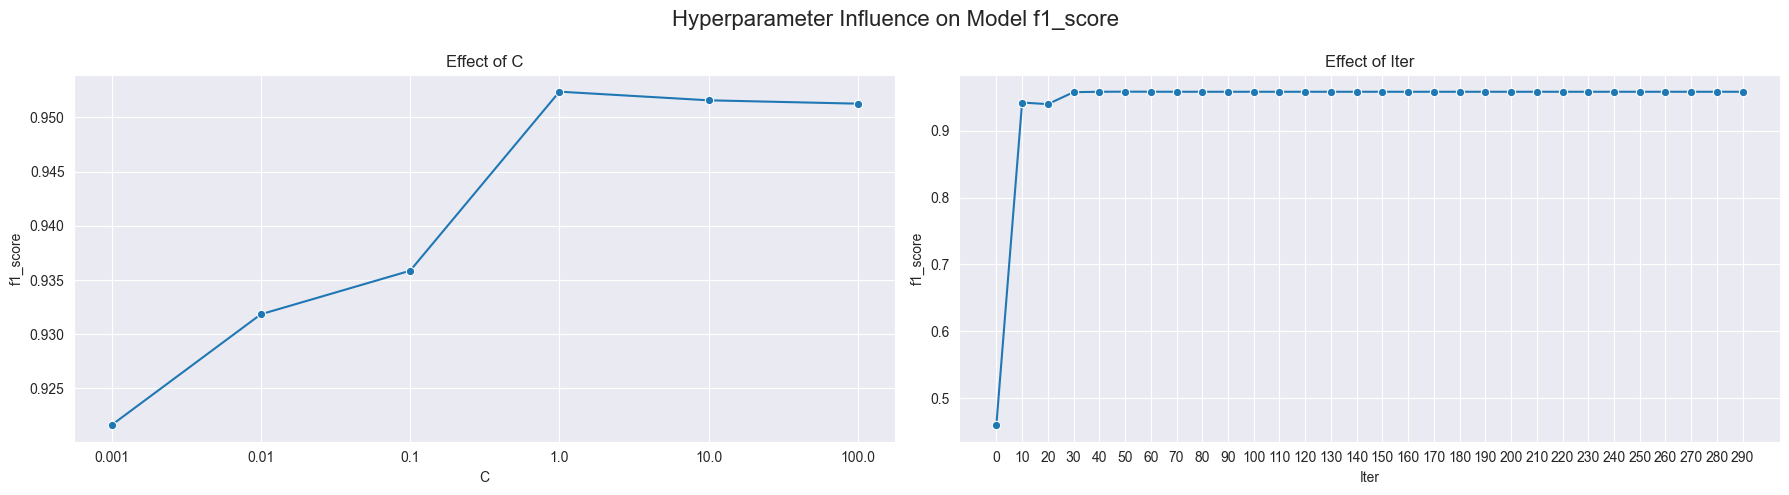

In [370]:
# Step 3: Extract results and prepare for visualization
results = pd.DataFrame(grid_search.cv_results_)

# List of hyperparameters to visualize
params = ['param_C', 'param_max_iter']

# Step 4: Create subplots to analyze the influence of each hyperparameter
fig, axes = plt.subplots(1, len(params), figsize=(18, 5))
fig.suptitle("Hyperparameter Influence on Model f1_score", fontsize=16)

# Plot each parameter's influence
for idx, param in enumerate(params):
    # Group results by the current parameter and calculate the mean test score
    param_means = results.groupby(param)['mean_test_score'].mean().reset_index()
    
    # Ensure categorical parameters are displayed correctly (e.g., 'criterion')
    param_means[param] = param_means[param].astype(str)
    
    # Line plot for accuracy against the parameter
    sns.lineplot(data=param_means, x=param, y='mean_test_score', ax=axes[idx], marker='o')
    axes[idx].set_title(f"Effect of {param.split('_')[-1].capitalize()}")
    axes[idx].set_ylabel("f1_score")
    axes[idx].set_xlabel(param.split('_')[-1].capitalize())

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

As we can observe from the code, the procedure for implementing Stacking follows a series of steps. First, datasets are created to train both the base models and the blender layer. The base models are trained on one dataset, while the blender is trained on another dataset that is generated from the predictions of the base models.

- Step 1: Training Base Models
The base models, including a Decision Tree, Random Forest, and AdaBoost, are trained on the `X_base` dataset (which is a subset of the training data). These models generate predictions that are used as features for the blender model.

-  Step 2: Training the Blender Model
The blender model is a logistic regression classifier (`LogisticRegression()`), chosen for its simplicity. The predictions generated by the base models for the `X_blender` dataset are used as features to train the blender. These predictions are stacked together into a new feature matrix, `X_blender_features`, which is used to fit the blender model.

-  Step 3: Hyperparameter Tuning
A hyperparameter grid search is performed using `GridSearchCV` to find the best hyperparameters for the blender model. The parameters being tuned include:
- **C**: Regularization strength, with values ranging from 0.001 to 100.
- **max_iter**: Maximum number of iterations for convergence, tested over a range of values.

-  Step 4: Analysis of Hyperparameter Influence
Once the grid search is complete, we analyze the influence of these hyperparameters on the `f1_score` of the blender model. The results are visualized using line plots for each parameter. Based on the plots:
- **C**: The optimal value of `C` is found to be 1, as it provides a high `f1_score` without reducing regularization too much.
- **max_iter**: From the plots, we observe that increasing `max_iter` beyond 20 does not lead to any significant improvement in generalization, so the value of 20 is selected.




In [371]:
best_blender = LogisticRegression(solver="lbfgs",C=1,max_iter=100)

best_blender.fit(X_blender_features, y_blender)

# Step 7: Generate predictions for the Test Set using the base models
test_features = {
    'DecisionTree': best_decision_tree.predict(test_df_reduced),
    'RandomForest': best_rf.predict(test_df_reduced),
    'AdaBoost': ada_clf.predict(test_df_reduced)
}

# Stack the predictions to form the test set for the blender
X_test_features = np.column_stack(list(test_features.values()))

              precision    recall  f1-score   support

           0       1.00      0.91      0.95        32
           1       0.97      0.95      0.96       279
           2       0.97      0.96      0.96       472
           3       0.98      1.00      0.99       694

    accuracy                           0.97      1477
   macro avg       0.98      0.95      0.97      1477
weighted avg       0.97      0.97      0.97      1477

F1 Score (weighted): 97.42%


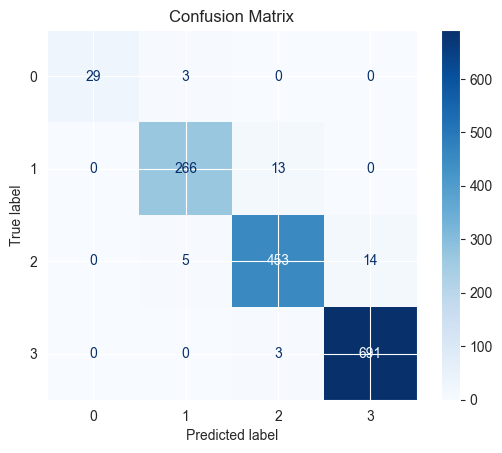

Rows where models disagree:
      DecisionTree  RandomForest  AdaBoost
121              2             2         1
123              2             3         2
200              3             3         2
240              3             3         2
250              3             3         2
257              2             2         3
282              2             3         3
296              2             1         2
319              2             1         2
347              0             1         1
372              2             3         3
374              1             1         2
392              2             3         3
402              2             2         1
478              3             3         2
486              2             2         1
522              1             1         2
564              1             2         2
580              1             1         2
599              2             3         1
637              2             2         1
702              2        

In [372]:
# Predict using the best blender model
y_pred_ensemble = best_blender.predict(X_test_features)
y_pred_ensemble_train = best_blender.predict(X_blender_features)

# Plot confusion matrix for the ensemble
plot_confusion_matrix(best_blender, y_test, y_pred_ensemble,True)

# Print rows where models disagree 
predictions_df = pd.DataFrame(test_features)

# Filter rows where the models disagree on the predicted class
disagreement_rows = predictions_df[
    ~predictions_df.eq(predictions_df.iloc[:, 0], axis=0).all(axis=1)
].copy()

# Display the disagreement rows
print("Rows where models disagree:")
print(disagreement_rows)
print(f"Total rows: {len(disagreement_rows)}")

The final F1 score of 96.87% indicates that the model is highly effective in correctly classifying the classes. For the analysis, both the confusion matrix and the classification report were used. 

From the **confusion matrix**, we can observe that the most represented class achieves a recall of 100%. However, the primary issues identified are:

- **Class 2** is often predicted as **Class 3**.
- **Class 1** is frequently predicted as **Class 2**.

These insights suggest areas where the model could be improved, especially for handling the misclassifications between Class £1 and Class 2, as well as Class 2 and Class 3.


As we can see from the plot of the decisions made by the three models, they only disagree in 67 instances. In all these cases, two models agree on the same prediction, highlighting a strong consensus among the base models.

In [373]:
# Evaluate the weighted F1 score for each model
Dt_f1 = f1_score(y_test, y_pred_decisiontree, average='weighted')
Rf_f1 = f1_score(y_test, y_pred_rf_, average='weighted')
Ab_f1 = f1_score(y_test, y_pred_ada, average='weighted')
Sv_f1 = f1_score(y_test, y_pred_voting, average='weighted')
St_f1 = f1_score(y_test,y_pred_ensemble,average='weighted')

# Print the weighted F1 scores for each model
print(Dt_f1, Rf_f1, Ab_f1, Sv_f1,St_f1)

0.9695491048894178 0.9728095717334933 0.9656679771714034 0.9769528158389681 0.974165426229422


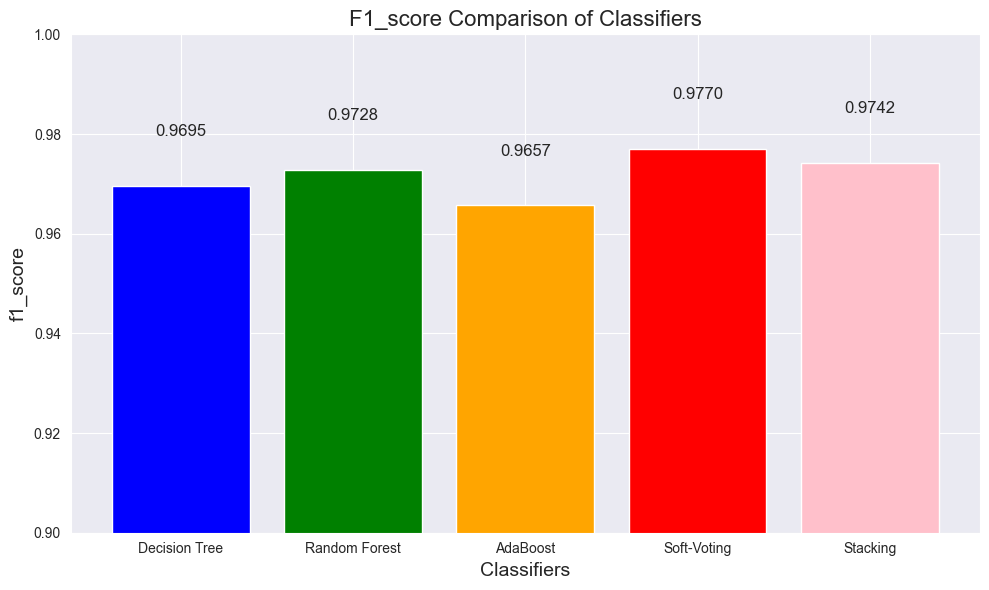

In [374]:
# Define the accuracy values
accuracy_values = [Dt_f1, Rf_f1, Ab_f1,Sv_f1,St_f1]
models = ['Decision Tree', 'Random Forest','AdaBoost','Soft-Voting','Stacking']

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_values, color=['blue', 'green', 'orange', 'red','pink'])

# Add title and labels
plt.title('F1_score Comparison of Classifiers', fontsize=16)
plt.xlabel('Classifiers', fontsize=14)
plt.ylabel('f1_score', fontsize=14)
plt.ylim([0.9, 1])  # Set y-axis limit to 0-1 for accuracy values

# Display the values on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()  # Get the height of the bar (accuracy value)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', fontsize=12)


# Show the plot
plt.tight_layout()
plt.show()

From the bar plot, we can see that the Stacking approach not outperforms Soft-Voting by achieving a F1 score of 0.97, compared to Soft-Voting's 0.977. This suggests that Soft_Voting is more effective.

# 8) Regression Build a regression model (e.g. MLP regressor) to predict the continuous target CO2 Emissions (g/hr), optimize its hyperparameters (e.g. number of layers, number of neurons per layer, and eventually the learning rate and the activation function), and evaluate its performance.

In [375]:
mlp_regressor = MLPRegressor(random_state=42, n_iter_no_change=10)

param_grid_mlp = {
    'hidden_layer_sizes': [(50,), (100,),(150,), (50, 50),(25,25,25)],
    'activation': ['relu', 'tanh'],
    'solver': ['adam'],
    'learning_rate_init': [0.001, 0.01,0.1,1],
    'max_iter': [50,100,150,300,500,700]
}

grid_search_mlp = GridSearchCV(mlp_regressor, param_grid_mlp, cv=5, n_jobs=-1, verbose=1)
grid_search_mlp.fit(train_df_scaled, y_train_reg)

mlp_best_model = grid_search_mlp.best_estimator_
print("Best Parameters for MLP Regressor:", grid_search_mlp.best_params_)

y_pred_mlp_reg = mlp_best_model.predict(test_df_scaled)

rmse = root_mean_squared_error(y_test_reg, y_pred_mlp_reg)
r2 = r2_score(y_test_reg, y_pred_mlp_reg)

print(f"RMSE: {rmse}")
print(f"R²: {r2}")


Fitting 5 folds for each of 240 candidates, totalling 1200 fits
Best Parameters for MLP Regressor: {'activation': 'relu', 'hidden_layer_sizes': (100,), 'learning_rate_init': 0.01, 'max_iter': 300, 'solver': 'adam'}
RMSE: 6.203586616994582
R²: 0.9885147710655278


The following hyperparameters were optimized for the **MLP Regressor**:

- **`hidden_layer_sizes`**: We tested different configurations for the hidden layers (e.g., `(50,)`, `(100,)`,`(50, 50)`, and `(25,25,25)`) to balance model complexity and performance.
  
- **`activation`**: We chose between `'relu'` and `'tanh'` to determine the best activation function for the problem.

- **`solver`**: The `'adam'` optimizer was selected for its efficient and fast convergence, especially in complex models.

- **`learning_rate_init`**: We tested different initial learning rates (`0.001`, `0.01`, `0.1`, and `1`) to find the optimal balance between speed and accuracy.

- **`max_iter`**: We varied the maximum number of iterations (`50`, `100`, `150`, `300`) to determine how many epochs are needed for the model to converge.

This tuning process ensures the model is well-optimized for predicting CO2 emissions.

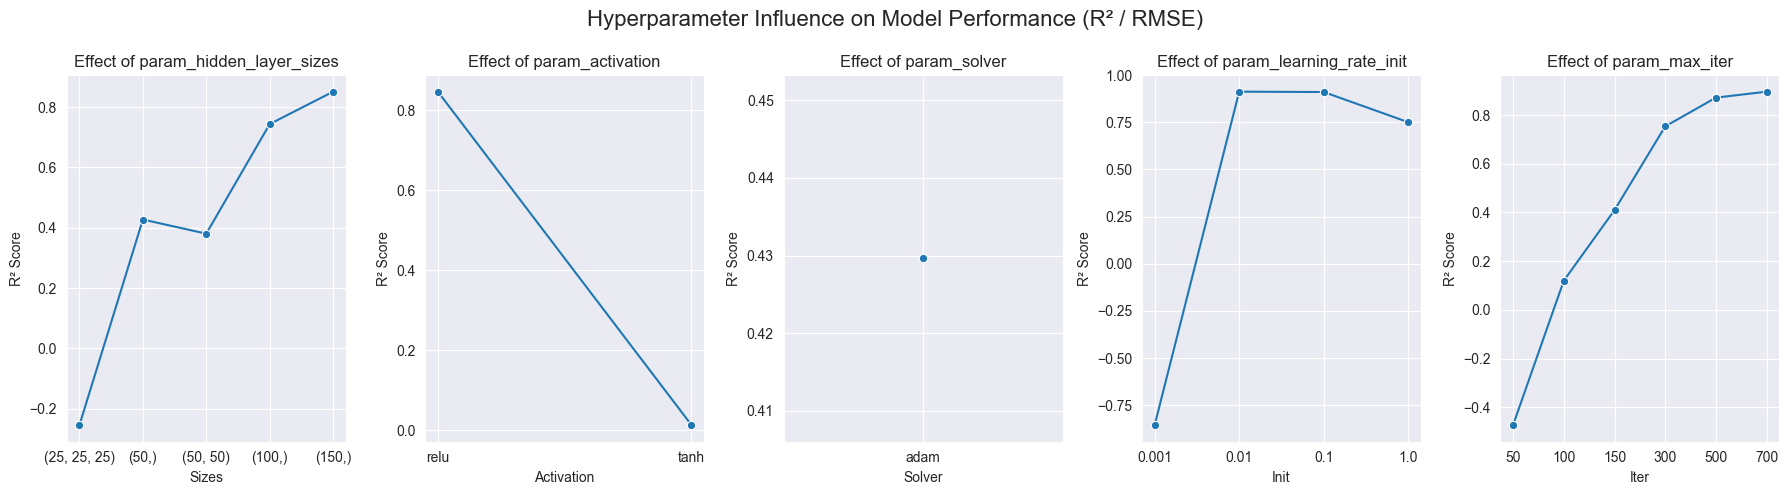

In [376]:
# Step 3: Extract results from the grid search
results = pd.DataFrame(grid_search_mlp.cv_results_)

# List of hyperparameters to visualize
params = ['param_hidden_layer_sizes', 'param_activation', 'param_solver', 'param_learning_rate_init','param_max_iter']

# Step 4: Create subplots to analyze the influence of each hyperparameter
fig, axes = plt.subplots(1, len(params), figsize=(18, 5))
fig.suptitle("Hyperparameter Influence on Model Performance (R² / RMSE)", fontsize=16)

# Plot each parameter's influence
for idx, param in enumerate(params):
    # Group results by the current parameter and calculate the mean R² score
    param_means = results.groupby(param)['mean_test_score'].mean().reset_index()
    
    # Convert the parameter values to string for better plotting
    param_means[param] = param_means[param].astype(str)
    
    # Line plot for R² against the parameter
    sns.lineplot(data=param_means, x=param, y='mean_test_score', ax=axes[idx], marker='o')
    axes[idx].set_title(f"Effect of {param}")
    axes[idx].set_ylabel("R² Score")
    axes[idx].set_xlabel(param.split('_')[-1].capitalize())

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

- **`hidden_layer_sizes`**: `(150,)` gives the best performance, with 150 neurons in a single hidden layer.
- **`activation`**: `'relu'` performs better than `'tanh'`, providing faster convergence and higher R² scores.
- **`solver`**: `'adam'` is the optimal solver, offering stable and efficient convergence.
- **`learning_rate_init`**: `0.1` is the best learning rate, balancing fast convergence without overshooting.
- **`max_iter`**: `500` iterations provide the best performance, avoiding both underfitting and excessive training time.

These hyperparameters lead to the highest R² score, indicating optimal model performance.

In [377]:
# Create the MLP Regressor model with the best hyperparameters
mlp_regressor = MLPRegressor(
    hidden_layer_sizes=(150,),     # Best hidden layer configuration
    activation='relu',              # Best activation function
    solver='adam',                 # Best solver
    learning_rate_init=0.1,       # Best learning rate
    max_iter=300,                  # Optimal number of iterations
    random_state=42,               # For reproducibility
    n_iter_no_change=10            # Stopping criterion
)

# Train the model on the scaled training data
mlp_regressor.fit(train_df_scaled, y_train_reg)

# Generate predictions for the test set
y_pred_mlp_reg = mlp_regressor.predict(test_df_scaled)

# Calculate RMSE and R² for evaluation
rmse = root_mean_squared_error(y_test_reg, y_pred_mlp_reg)
r2 = r2_score(y_test_reg, y_pred_mlp_reg)

# Print the evaluation metrics
print(f"RMSE: {rmse}")
print(f"R²: {r2}")


RMSE: 8.193181352681933
R²: 0.9799663957022049


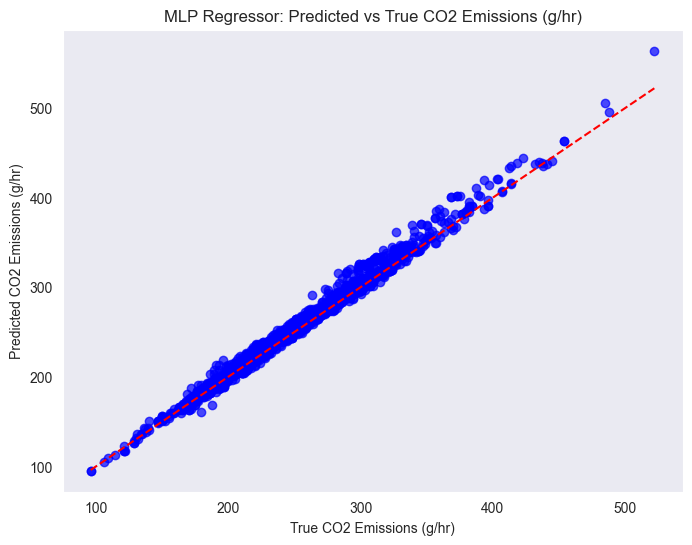

In [378]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test_reg, y_pred_mlp_reg, alpha=0.7, color='blue')
plt.plot([y_test_reg.min(), y_test_reg.max()], [y_test_reg.min(), y_test_reg.max()], 'r--')
plt.title('MLP Regressor: Predicted vs True CO2 Emissions (g/hr)')
plt.xlabel('True CO2 Emissions (g/hr)')
plt.ylabel('Predicted CO2 Emissions (g/hr)')
plt.grid()
plt.show()

- **RMSE**: The model achieves an **RMSE of 8.19**, indicating that the predicted CO2 emissions are quite close to the true values. This suggests the model is making accurate predictions with minimal error.

- **R²**: The **R² score of 0.97** shows that the model explains 97% of the variance in the CO2 emissions data, which is excellent for a regression task.

- **Predicted vs True CO2 Emissions**: The scatter plot demonstrates that the predicted CO2 emissions closely align with the true values. Most points are near the red dashed line (the ideal line where predicted values match the true values), suggesting strong predictive performance.

### 8.2) The model will output a continuous value: you should encode each predicted value in the best-matching target class and evaluate the model considering classification prediction metrics.

In [379]:
data = pd.DataFrame({'y_test': y_train, 'y_test_reg': y_train_reg})

# Group by class (0, 1, 2, 3) and calculate min and max for each class in y_test_reg
bin_limits = data.groupby('y_test')['y_test_reg'].agg(['min', 'max'])

print(bin_limits)

        min  max
y_test          
0        96  150
1       151  200
2       201  250
3       251  522


In [380]:
# Define the bin edges and labels
bin_edges = [96, 151, 201, 251, 522]  # Bin edges
bin_labels = [0, 1, 2, 3]  # Class labels

In [381]:
# Apply binning to the predictions
y_pred_binned = pd.cut(y_pred_mlp_reg, bins=bin_edges, labels=bin_labels, include_lowest=True)

# Replace NaN values with class 3 (the highest class)
y_pred_binned = y_pred_binned.fillna(3)  # Assign class 3 to NaN values (out of bounds)

# Display the binned predictions
print(y_pred_binned)

[3, 3, 3, 2, 3, ..., 2, 0, 2, 3, 3]
Length: 1477
Categories (4, int64): [0 < 1 < 2 < 3]


To compare the predictions made by the regression model with those from the classification model, we can apply a common approach. After obtaining the regression predictions, we first determine the boundaries of the categorical values (or classes). By using appropriate **binning**, we transform the continuous predicted values into discrete classes (e.g., [0, 1, 2, 3]).

Once the continuous values are binned into classes, we can evaluate the model performance using a **confusion matrix** or a **classification report**. This allows us to directly compare how the regression-based model's predictions align with the classification model's outputs.



  

### 8.3) . Finally, compare the performance with respect to the best model trained in the previous points.

In [387]:
# Evaluate the weighted F1 score for each model
sf_f1 = f1_score(y_test, y_pred_voting, average='weighted')
reg_f1 = f1_score(y_test,y_pred_binned,average='weighted')

# Print the weighted F1 scores for each model
print(sf_f1, reg_f1)

0.9769528158389681 0.9349888886863275


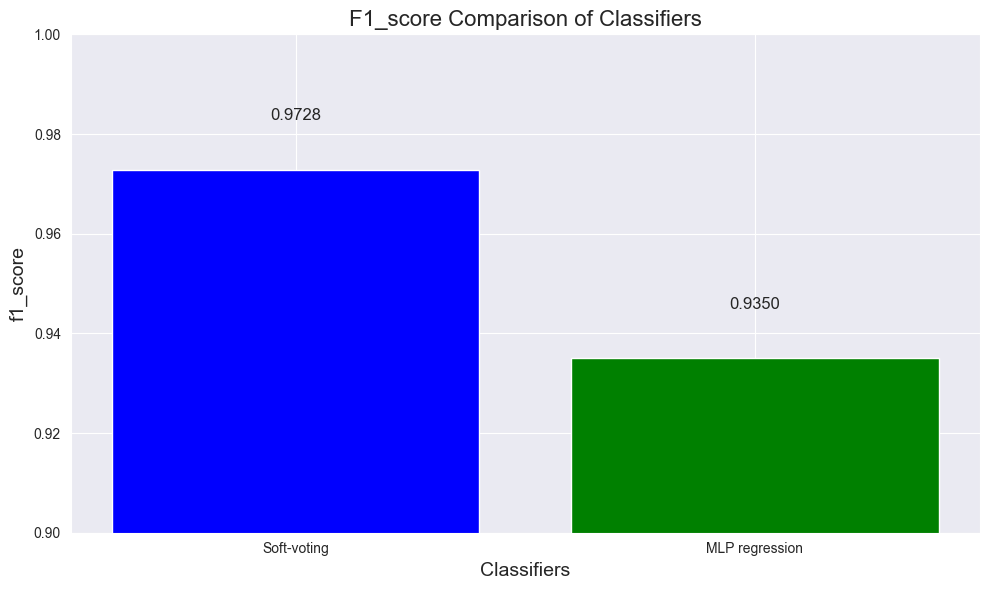

In [388]:
# Define the accuracy values
accuracy_values = [Rf_f1,reg_f1]
models = ['Soft-voting','MLP regression']

# Create the bar plot
plt.figure(figsize=(10, 6))
bars = plt.bar(models, accuracy_values, color=['blue', 'green'])

# Add title and labels
plt.title('F1_score Comparison of Classifiers', fontsize=16)
plt.xlabel('Classifiers', fontsize=14)
plt.ylabel('f1_score', fontsize=14)
plt.ylim([0.9, 1])  # Set y-axis limit to 0-1 for accuracy values

# Display the values on top of the bars
for i, bar in enumerate(bars):
    height = bar.get_height()  # Get the height of the bar (accuracy value)
    plt.text(bar.get_x() + bar.get_width() / 2, height + 0.01, f'{height:.4f}', ha='center', fontsize=12)


# Show the plot
plt.tight_layout()
plt.show()

We can observe that while the **MLP Regressor** performs well, the **Soft-Voting** continues to be the best-performing model. 



# 9) Final results:

In [384]:
sf_train = f1_score(y_train,y_pred_softmax_cv_train,average='weighted')
sf_test = f1_score(y_test,y_pred_softmax_cv,average='weighted')

dt_train = f1_score(y_train,y_pred_decisiontree_train,average='weighted')
dt_test = f1_score(y_test,y_pred_decisiontree,average='weighted')

rf_train = f1_score(y_train,y_pred_rf_train,average='weighted')
rf_test = f1_score(y_test,y_pred_rf_,average='weighted')

ab_train = f1_score(y_train,y_pred_ada_train,average='weighted')
ab_test = f1_score(y_test,y_pred_ada,average='weighted')

sv_train = f1_score(y_train,y_pred_voting_train,average='weighted')
sv_test = f1_score(y_test,y_pred_voting,average='weighted')

st_test = f1_score(y_test,y_pred_ensemble,average='weighted')

reg_test = f1_score(y_test,y_pred_binned,average='weighted')


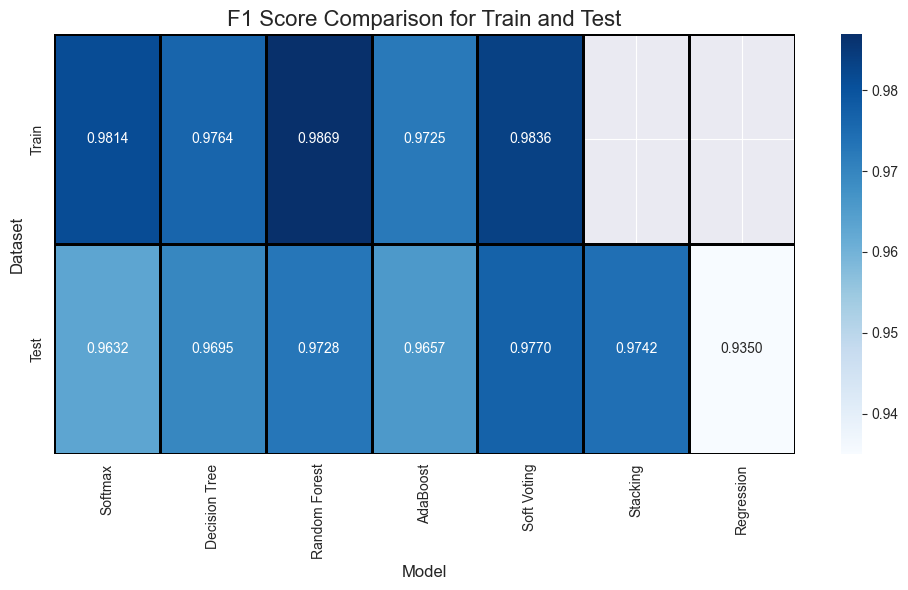

In [385]:
# Create a dictionary of the F1 scores for each model (train and test)
f1_scores = {
    'Softmax': [sf_train, sf_test],
    'Decision Tree': [dt_train, dt_test],
    'Random Forest': [rf_train, rf_test],
    'AdaBoost': [ab_train, ab_test],
    'Soft Voting': [sv_train, sv_test],
    'Stacking': [None, st_test],
    'Regression': [None, reg_test]  # Regression only has the test score
}

# Convert the dictionary into a DataFrame
f1_df = pd.DataFrame(f1_scores, index=['Train', 'Test'])

# Create the heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(f1_df, annot=True, cmap='Blues', fmt=".4f", cbar=True, linewidths=1, linecolor='black')

# Title and labels
plt.title('F1 Score Comparison for Train and Test', fontsize=16)
plt.xlabel('Model', fontsize=12)
plt.ylabel('Dataset', fontsize=12)

# Show the plot
plt.tight_layout()
plt.show()